# Dataset Configuration

In [99]:
import yaml
from types import SimpleNamespace

with open("configurations/pickleball_config.yaml", "r") as file:
    config_dict = yaml.safe_load(file)

# Convert to a namespace so you can use dot notation (config.SEED instead of config["SEED"])
config = SimpleNamespace(**config_dict)

print(f"Loading data from: {config.DATA_PATH}")

Loading data from: datasets/pickleball_dataset.csv


# Setup

In [100]:
import torch
import numpy as np
import random

def set_seed(seed=config.SEED):
    """Set the seed for all random generators (for reproducibility)"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call the function
set_seed(config.SEED)

# Loading Dataset

In [101]:
import pandas as pd

# Load the dataset from csv
full_dataset = pd.read_csv(config.DATA_PATH)

# Drop missing values
full_dataset = full_dataset.dropna()

print(full_dataset.head())


            Timestamp             Email Address       Date Day of the Week  \
0  4/24/2026 15:30:29  joshuasanty100@gmail.com  4/19/2026          Sunday   
1  4/24/2026 15:31:13  joshuasanty100@gmail.com  4/23/2026        Thursday   
2  4/24/2026 15:31:53  joshuasanty100@gmail.com  4/23/2026        Thursday   

  Time (Hourly)  Number of Groups (Don't include your own group!)  \
0    6:00:00 PM                                                 8   
1    3:00:00 PM                                                 3   
2    5:00:00 PM                                                 4   

   Number of People (Don't include your own people!)  Temperature  \
0                                                 35           65   
1                                                  7           80   
2                                                 10           80   

         Weather  \
0          Sunny   
1  Partly Cloudy   
2  Partly Cloudy   

   Wind Level (0=none, 1=light breeze, 2=wind affect

In [102]:
# Display details for each column
for col, dtype in zip(full_dataset.columns, full_dataset.dtypes):
    print(f"{col} ({str(dtype)}): {full_dataset[col].nunique()} unique values")


Timestamp (str): 3 unique values
Email Address (str): 1 unique values
Date (str): 2 unique values
Day of the Week (str): 2 unique values
Time (Hourly) (str): 3 unique values
Number of Groups (Don't include your own group!) (int64): 3 unique values
Number of People (Don't include your own people!) (int64): 3 unique values
Temperature (int64): 2 unique values
Weather (str): 2 unique values
Wind Level (0=none, 1=light breeze, 2=wind affecting ball, 3=strong gusts) (int64): 2 unique values


In [103]:
# Statistical data for each column
print(full_dataset.describe())


       Number of Groups (Don't include your own group!)  \
count                                          3.000000   
mean                                           5.000000   
std                                            2.645751   
min                                            3.000000   
25%                                            3.500000   
50%                                            4.000000   
75%                                            6.000000   
max                                            8.000000   

       Number of People (Don't include your own people!)  Temperature  \
count                                           3.000000     3.000000   
mean                                           17.333333    75.000000   
std                                            15.373137     8.660254   
min                                             7.000000    65.000000   
25%                                             8.500000    72.500000   
50%                           

# Data Pre-Processing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Filter as needed
if config.FILTER_COLUMN and config.FILTER_VALUE is not None:
    dataset = full_dataset[full_dataset[config.FILTER_COLUMN] == config.FILTER_VALUE].reset_index(drop=True)
    print(f"Filtered to {config.FILTER_COLUMN} == '{config.FILTER_VALUE}': {len(dataset)} rows")
else:
    dataset = full_dataset.copy()

# Drop unwanted columns
cols_to_drop = [c for c in config.DROP_COLUMNS if c in dataset.columns]
dataset = dataset.drop(columns=cols_to_drop)

# Remove unwanted category variables
if config.EXCLUDE_CATEGORY_VALUES:
    for col, bad_vals in config.EXCLUDE_CATEGORY_VALUES.items():
        if col in dataset.columns:
            before = len(dataset)
            dataset = dataset[~dataset[col].isin(bad_vals)].copy()
            print(f"Dropped {before - len(dataset)} rows where {col} in {bad_vals}")

# Apply ordinal mappings
ordinal_mapped = {}   # stores the mapped numeric series for interaction terms
if config.ORDINAL_MAPPINGS:
    for col, mapping in config.ORDINAL_MAPPINGS.items():
        if col in dataset.columns:
            ordinal_mapped[col] = dataset[col].map(mapping)

# Add interaction terms
interaction_term_names = []
if config.INTERACTION_TERMS is not None:
    for col_a, col_b in config.INTERACTION_TERMS:
        term_name = f"{col_a.replace(' ', '_')}_x_{col_b.replace(' ', '_')}"
        # Use ordinal-mapped version if available, otherwise raw column
        val_a = ordinal_mapped.get(col_a, dataset[col_a])
        val_b = ordinal_mapped.get(col_b, dataset[col_b])
        dataset[term_name] = val_a * val_b
        interaction_term_names.append(term_name)
        print(f"Created interaction term: {term_name}")

# Separate the target variable (y)
X = dataset.drop(config.TARGET_COLUMN, axis=1)
if config.TARGET_ENCODING is not None:
    y = dataset[config.TARGET_COLUMN].map(config.TARGET_ENCODING)
else:
    y = dataset[config.TARGET_COLUMN]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SET_FRACTION, random_state=config.SEED, stratify=y
)

# Group columns by data type
all_numeric = [f for f in config.NUMERIC_FEATURES if f in X.columns] + interaction_term_names
all_categorical = [f for f in config.CATEGORICAL_FEATURES if f in X.columns]

print(f"\nNumeric features  : {all_numeric}")
print(f"Categorical features: {all_categorical}")

# Column transformer will convert data into usable numeric values for models to use
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical values are already the correct type, so just scale to unit variance
        ('num', StandardScaler(), all_numeric),
        # Categorical variables are one-hot encoded, and then drop the first of each category (so we don't have two variables each for True/False values)
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), all_categorical)
    ]
)

# Apply the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [3, 4, 8]

# Functions/Tools

## Model Evaluation Tools

In [ ]:
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import torch
import torch.nn as nn

def evaluate_model(model, X_test, y_test, name="Model", show_plots=True, threshold=0.5):
    """Evaluate the provided model. Calculates a variety of metrics and (optionally) displays results"""
    metrics = {"Model": name}
    y_proba = None
    y_score = None

    # Handle PyTorch models
    if isinstance(model, nn.Module):
        model.eval()
        # Convert to tensor
        if not torch.is_tensor(X_test):
            if hasattr(X_test, "toarray"):
                X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
            else:
                X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        else:
            X_test_tensor = X_test

        with torch.no_grad():
            outputs = model(X_test_tensor)
            if outputs.shape[1] == 1:
                y_proba = outputs.squeeze().cpu().numpy()
            else:
                y_proba = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

    elif hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        
        # Apply the threshold
        y_pred = (y_proba >= threshold).astype(int)
    
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)
        metrics["Brier_Score"] = None
        
        # Fallback to standard prediction if no probabilities
        y_pred = model.predict(X_test)

    else:
        y_pred = model.predict(X_test)
        metrics["ROC-AUC"] = None
        metrics["Brier_Score"] = None

    # Calculate other prediction metrics
    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1_Score"] = f1_score(y_test, y_pred, zero_division=0)
    metrics["MCC"] = matthews_corrcoef(y_test, y_pred)
    metrics["AP"] = average_precision_score(y_test, y_score) if y_score is not None else None

    # Display the results
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    if metrics["ROC-AUC"] is not None:
        print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    if metrics["Brier_Score"] is not None:
        print(f"Brier Score: {metrics['Brier_Score']:.4f}")
    print(f"MCC: {metrics['MCC']:.4f}")

    if show_plots:
        # Display the confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Depressed", "Depressed"]
        )
        disp.plot(cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        
        if y_proba is not None:
            # Display the ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)

            # Compute Precision-Recall
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # ROC Curve
            axes[0].plot(fpr, tpr, label=f"AUC = {metrics["ROC-AUC"]:.3f}")
            axes[0].plot([0, 1], [0, 1], linestyle="--")
            axes[0].set_xlabel("False Positive Rate")
            axes[0].set_ylabel("True Positive Rate")
            axes[0].set_title(f"{name} ROC Curve")
            axes[0].legend()
        
            # Precision-Recall Curve
            baseline = sum(y_test) / len(y_test)
            axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
            axes[1].hlines(baseline, 0, 1, linestyles="--", label="Baseline")
            axes[1].set_xlabel("Recall")
            axes[1].set_ylabel("Precision")
            axes[1].set_title(f"{name} Precision-Recall Curve")
            axes[1].legend()

            plt.tight_layout()

        plt.show()

    return metrics

def show_feature_importance(model, preprocessor, top_n=10):
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    feature_importance = feature_importance.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(f"\n--- Top {top_n} Features Increasing Risk ---")
    print(feature_importance.head(top_n).to_string(index=False))

    print(f"\n--- Top {top_n} Features Decreasing Risk ---")
    print(feature_importance.tail(top_n).to_string(index=False))

def cross_validate_model(model, X, y, cv=5, scoring="roc_auc", name="Model"):
    """Perform K-fold cross validation, returning the list of scores"""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    print(f"\n--- {name} {cv}-Fold Cross-Validation ({scoring}) ---")
    print(f"Individual Fold Scores: {['{:.4f}'.format(s) for s in scores]}")
    print(f"Mean Score: {scores.mean():.4f}")
    print(f"Standard Deviation: +/- {scores.std():.4f}")
    
    return scores

def evaluate_sparsity(model) -> int:
    coef = model.coef_[0]
    non_zero = np.sum(coef != 0)
    total = len(coef)
    print(f"Non-zero features: {non_zero}")
    print(f"Total features: {total}")
    print(f"Sparsity: {100 * (1 - non_zero/total):.2f}% features removed")
    return non_zero


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_gridsearch_param(
    grid_search,
    param_name: str,
    use_log_scale: bool = True,
    selected_value: float = None
):
    """Plot score vs. a hyperparameter (to select best value for a minimal model)"""
    results = pd.DataFrame(grid_search.cv_results_)

    param_col = f"param_{param_name}"
    if param_col not in results:
        raise ValueError(f"Parameter '{param_name}' not found.")

    x = results[param_col].astype(float)
    y = results["mean_test_score"]
    std = results["std_test_score"]

    # Sort for clean plotting
    order = np.argsort(x)
    x, y, std = x.iloc[order], y.iloc[order], std.iloc[order]

    # Best point
    best_idx = y.idxmax()
    best_x = results.loc[best_idx, param_col]
    best_y = results.loc[best_idx, "mean_test_score"]
    best_std = results.loc[best_idx, "std_test_score"]

    upper = best_y + best_std
    lower = best_y - best_std

    plt.figure()

    # Main curve
    plt.plot(x, y, marker="o", label="Mean CV Score")

    # Highlight best point
    plt.scatter(best_x, best_y, color="red", zorder=3, label="Best")

    # Horizontal std band
    plt.axhspan(lower, upper, alpha=0.15, label="±1 std (best)")

    if selected_value is not None:
        selected_value = float(selected_value)
        selected_y = np.interp(selected_value, x, y)  # approximate y-position

        plt.scatter(
            selected_value,
            selected_y,
            color="green",
            s=100,
            zorder=4,
            label=f"Selected {param_name} = {selected_value:.4f}"
        )
        plt.axvline(selected_value, color="red", linestyle="--", alpha=0.5)

    plt.xlabel(param_name)
    plt.ylabel("Mean Test Score")
    plt.title(f"{param_name} vs Cross-Validated Score")
    plt.grid(True)

    if use_log_scale:
        plt.xscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def find_best_threshold(y_true, y_proba, target_recall=None, target_precision=None):
    """Find threshold based on target recall or precision"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # Fix array size difference

    # Target recall
    if target_recall is not None:
        valid_idx = np.where(recall >= target_recall)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(precision[valid_idx])]

    # Target precision
    elif target_precision is not None:
        valid_idx = np.where(precision >= target_precision)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(recall[valid_idx])]

    else:
        raise ValueError("Provide either target_recall or target_precision")

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

# Logistic Regression

## Standard (All predictors)


--- Standard LR 10-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.8211', '0.7261', '0.7900', '0.8848', '0.8852', '0.8870', '0.8741', '0.8717', '0.7744', '0.8073']
Mean Score: 0.8322
Standard Deviation: +/- 0.0539

--- Full (10 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       201
           1       0.74      0.70      0.72       200

    accuracy                           0.73       401
   macro avg       0.73      0.73      0.73       401
weighted avg       0.73      0.73      0.73       401

ROC-AUC: 0.8118
Brier Score: 0.1775
MCC: 0.4519


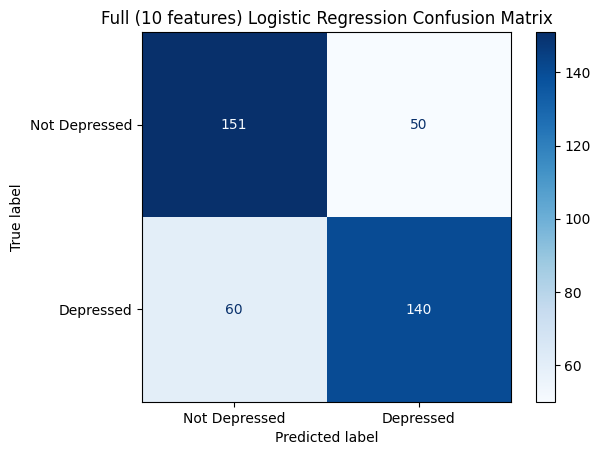

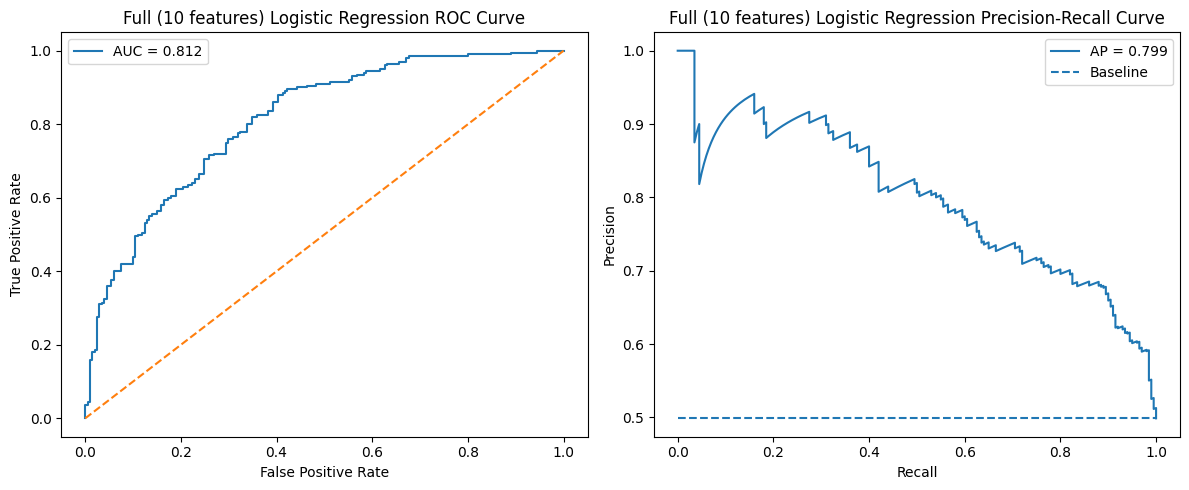


--- Top 10 Features Increasing Risk ---
        Feature  Coefficient
num__AdjOE_diff     1.705087
  num__DRB_diff     0.320940
num__EFGD%_diff     0.193192
  num__TOR_diff     0.012780
  num__ORB_diff    -0.051642
 num__EFG%_diff    -0.059429
 num__TORD_diff    -0.067034
num__ADJ T_diff    -0.116831
  num__WAB_diff    -0.648851
num__AdjDE_diff    -1.567941

--- Top 10 Features Decreasing Risk ---
        Feature  Coefficient
num__AdjOE_diff     1.705087
  num__DRB_diff     0.320940
num__EFGD%_diff     0.193192
  num__TOR_diff     0.012780
  num__ORB_diff    -0.051642
 num__EFG%_diff    -0.059429
 num__TORD_diff    -0.067034
num__ADJ T_diff    -0.116831
  num__WAB_diff    -0.648851
num__AdjDE_diff    -1.567941


In [ ]:
from sklearn.linear_model import LogisticRegression

# Build the logistic regression model ("balanced" means classes are given equal weight)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=config.SEED)

# Train the model
log_reg.fit(X_train_processed, y_train)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg, X_train_processed, y_train, cv=10, name="Standard LR")

# Evaluate the model
base_lr_metrics = evaluate_model(log_reg, X_test_processed, y_test, f"Full ({len(log_reg.coef_[0])} features) Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg, preprocessor)


## Sparse (Using Lasso Regression)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Optimal 'C' within margin: 0.0112


d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


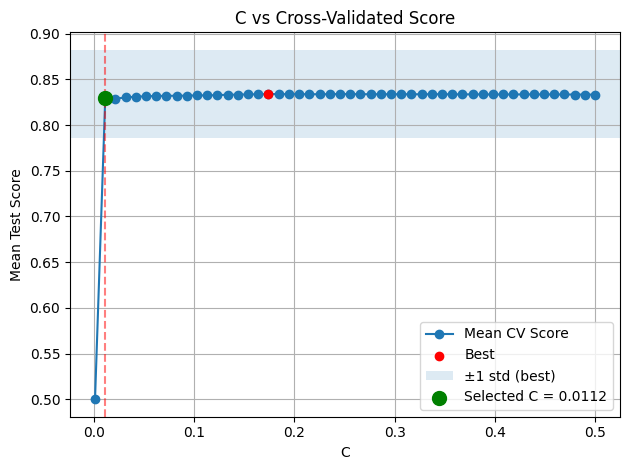

d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Non-zero features: 2
Total features: 10
Sparsity: 80.00% features removed


d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Programming\Stats-Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in


--- Sparse (2 features) LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.7678', '0.8400', '0.8754', '0.8855', '0.7770']
Mean Score: 0.8291
Standard Deviation: +/- 0.0488
Threshold Details: (Threshold = 0.5 | Precision = None | Recall = None

--- Sparse (2 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       201
           1       0.72      0.69      0.70       200

    accuracy                           0.71       401
   macro avg       0.71      0.71      0.71       401
weighted avg       0.71      0.71      0.71       401

ROC-AUC: 0.8044
Brier Score: 0.1861
MCC: 0.4219


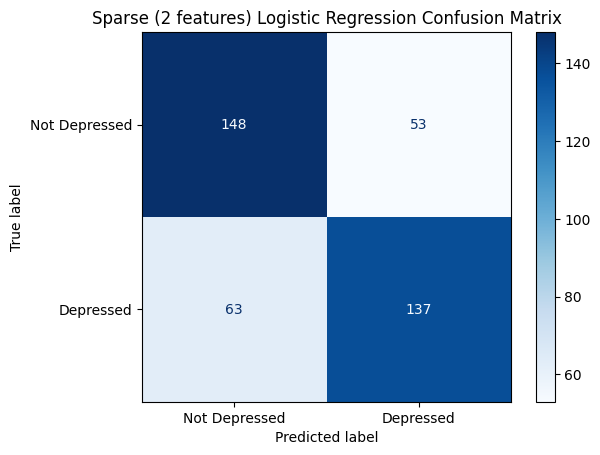

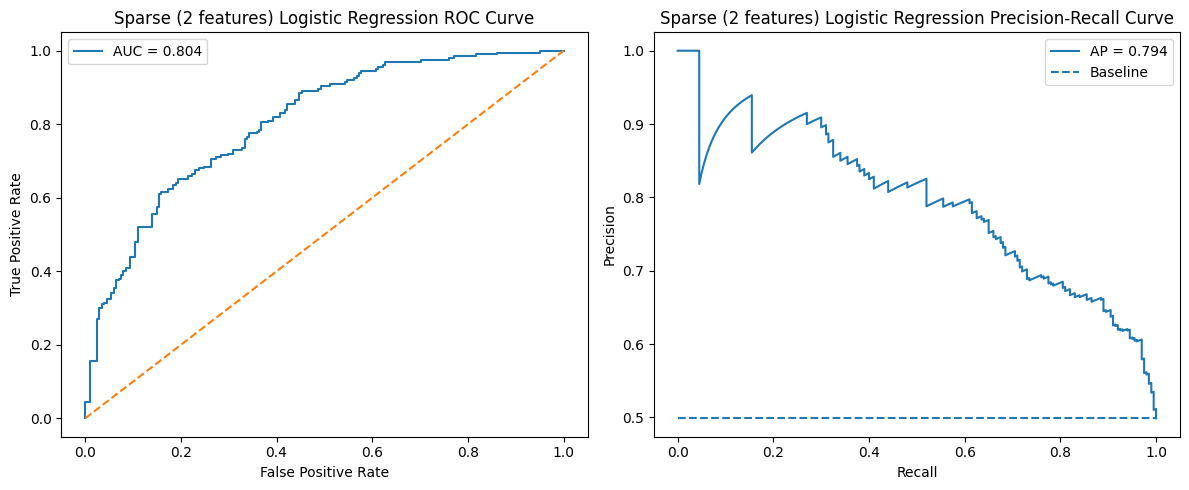


--- Top 10 Features Increasing Risk ---
        Feature  Coefficient
num__AdjOE_diff     0.716231
 num__EFG%_diff     0.000000
  num__ORB_diff     0.000000
num__EFGD%_diff     0.000000
  num__TOR_diff     0.000000
 num__TORD_diff     0.000000
num__ADJ T_diff     0.000000
  num__DRB_diff     0.000000
  num__WAB_diff     0.000000
num__AdjDE_diff    -0.563110

--- Top 10 Features Decreasing Risk ---
        Feature  Coefficient
num__AdjOE_diff     0.716231
 num__EFG%_diff     0.000000
  num__ORB_diff     0.000000
num__EFGD%_diff     0.000000
  num__TOR_diff     0.000000
 num__TORD_diff     0.000000
num__ADJ T_diff     0.000000
  num__DRB_diff     0.000000
  num__WAB_diff     0.000000
num__AdjDE_diff    -0.563110


In [ ]:
from sklearn.model_selection import GridSearchCV

# Tuning flag - If performance is bad, disable this! (model will use pre-tuned C value from my testing)
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        penalty='l1',
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=config.SEED
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid={'C': np.linspace(0.001, 0.5, 50)},
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    acceptable_threshold = best_score - results.loc[best_index, 'std_test_score']

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_sparse = LogisticRegression(
    penalty='l1', 
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=config.SEED
)
log_reg_sparse.fit(X_train_processed, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_sparse)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_sparse, X_train_processed, y_train, cv=5, name=f"Sparse ({num_features} features) LR")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_sparse.predict_proba(X_test_processed)[:, 1]
if config.THRESHOLD_STRATEGY == "recall":
    threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=config.THRESHOLD_TARGET)
elif config.THRESHOLD_STRATEGY == "precision":
    threshold_result = find_best_threshold(y_test, y_proba_test, target_precision=config.THRESHOLD_TARGET)
else:
    # Default threshold
    threshold_result = {"threshold": 0.5, "precision": None, "recall": None}

print(f"Threshold Details: (Threshold = {threshold_result["threshold"]} | Precision = {threshold_result["precision"]} | Recall = {threshold_result["recall"]}")

# Evaluate the model
sparse_lr_metrics = evaluate_model(log_reg_sparse, X_test_processed, y_test, f"Sparse ({num_features} features) Logistic Regression", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_sparse, preprocessor)

# Deep Learning

## Tools

In [ ]:
import copy

def train_model(model, train_loader, val_loader, optimizer, criterion, lr_scheduler, params):
    """Train the provided model using the provided training and validation data (+params for other variables)"""
    
    best_val_loss = float('inf')
    best_model_wts = None
    patience = params.get("patience", 10)
    counter = 0
    
    for epoch in range(100):
        model.train()
        running_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        
        avg_train_loss = running_train_loss / len(train_loader)
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_vx, batch_vy in val_loader:
                outputs = model(batch_vx)
                val_loss += criterion(outputs, batch_vy).item()
        
        avg_val_loss = val_loss / len(val_loader)

        lr_scheduler.step(avg_val_loss)
        
        print(f"Epoch [{epoch+1:2d}/100] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"\n--- Early Stopping Triggered! ---")
                print(f"No improvement for {patience} consecutive epochs.")
                break
                
    if best_model_wts:
        model.load_state_dict(best_model_wts)
    
    return model


## Data Pre-Processing

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Create the validation set (split the training set again)
X_train_dl, X_val, y_train_dl, y_val = train_test_split(
    X_train_processed, 
    y_train, 
    test_size=0.2, 
    random_state=config.SEED, 
    stratify=y_train
)

def to_tensor(data):
    if hasattr(data, "toarray"): data = data.toarray()
    return torch.tensor(data, dtype=torch.float32)

# Convert to tensors
X_train_t = to_tensor(X_train_dl)
y_train_t = torch.tensor(y_train_dl.values, dtype=torch.float32).view(-1, 1)
X_val_t = to_tensor(X_val)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Build data loaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print(f"Data ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Data ready. Train batches: 20 | Val batches: 6


## Multi-Layer Perceptron

In [ ]:
class BinaryMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Build the model, and select an optimizer (for learning rate) and a criterion to check
params = {
    'hidden': [128, 64], 
    'dropout': 0.3, 
    'lr': 0.001, 
    'wd': 1e-5,
    'patience': 10
}
model = BinaryMLP(input_dim=X_train_t.shape[1], hidden_dims=params["hidden"], dropout_rate=params["dropout"])
optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["wd"])
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)


In [ ]:
# Train the model (with early stopping)
model = train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, params)

Epoch [ 1/100] | Train Loss: 0.6358 | Val Loss: 0.5688
Epoch [ 2/100] | Train Loss: 0.5503 | Val Loss: 0.4919
Epoch [ 3/100] | Train Loss: 0.5344 | Val Loss: 0.4836
Epoch [ 4/100] | Train Loss: 0.5225 | Val Loss: 0.4787
Epoch [ 5/100] | Train Loss: 0.5176 | Val Loss: 0.4801
Epoch [ 6/100] | Train Loss: 0.5145 | Val Loss: 0.4762
Epoch [ 7/100] | Train Loss: 0.5151 | Val Loss: 0.4811
Epoch [ 8/100] | Train Loss: 0.5048 | Val Loss: 0.4786
Epoch [ 9/100] | Train Loss: 0.5112 | Val Loss: 0.4798
Epoch [10/100] | Train Loss: 0.5004 | Val Loss: 0.4772
Epoch [11/100] | Train Loss: 0.4997 | Val Loss: 0.4804
Epoch [12/100] | Train Loss: 0.4933 | Val Loss: 0.4785
Epoch [13/100] | Train Loss: 0.5004 | Val Loss: 0.4774
Epoch [14/100] | Train Loss: 0.5008 | Val Loss: 0.4796
Epoch [15/100] | Train Loss: 0.4955 | Val Loss: 0.4787
Epoch [16/100] | Train Loss: 0.4966 | Val Loss: 0.4784

--- Early Stopping Triggered! ---
No improvement for 10 consecutive epochs.



--- Deep Learning MLP Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       201
           1       0.73      0.66      0.69       200

    accuracy                           0.71       401
   macro avg       0.71      0.71      0.71       401
weighted avg       0.71      0.71      0.71       401

ROC-AUC: 0.7792
Brier Score: 0.1937
MCC: 0.4182


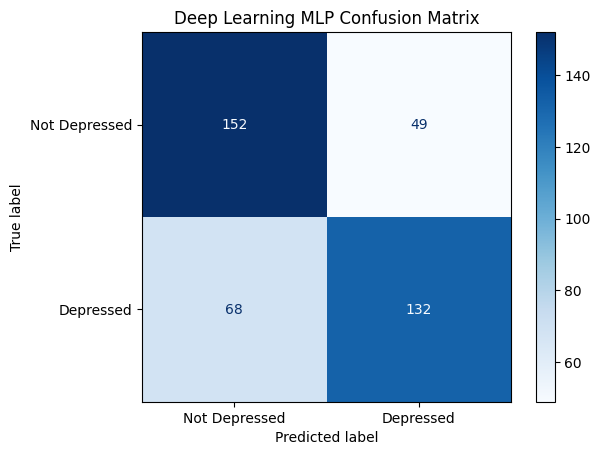

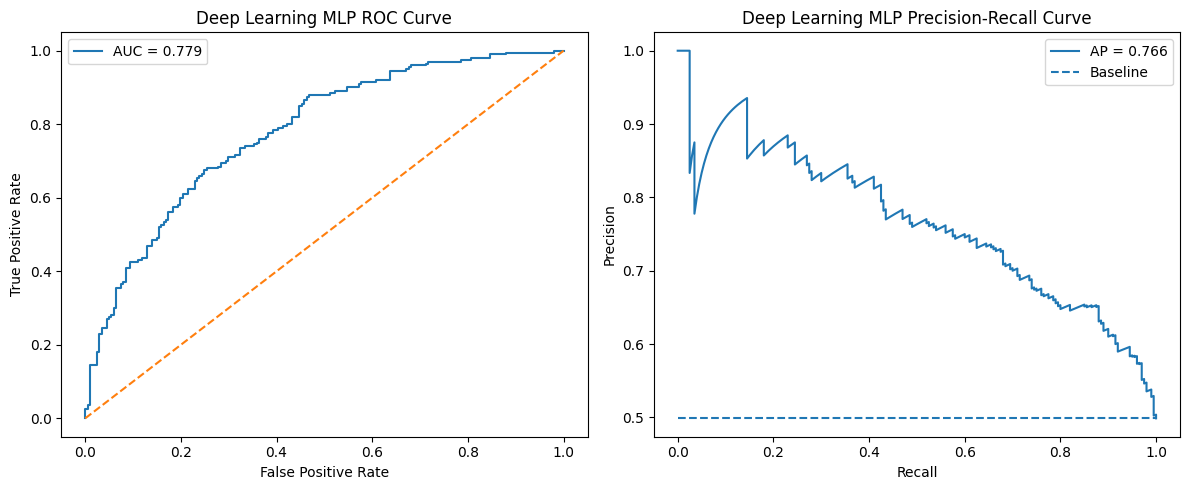

In [ ]:
dl_mlp_metrics = evaluate_model(
    model=model, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Deep Learning MLP",
    threshold=0.5
)

# K-Nearest Neighbors (KNN)

Starting Grid Search for KNN...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- Grid Search Results ---
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 41, 'weights': 'uniform'}
Best Cross-Validation AUC: 0.8116


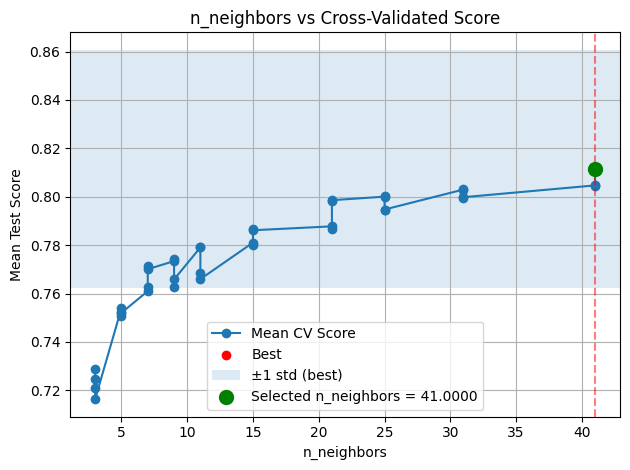

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#Initialize the base model
knn = KNeighborsClassifier()

# Define the hyperparameter grid
# We use odd numbers for n_neighbors to prevent tie-breaking issues.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25, 31, 41],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up GridSearchCV
print("Starting Grid Search for KNN...")
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc',   # Optimizing for Area Under the ROC Curve
    n_jobs=-1,           # Use all available CPU cores to speed up processing
    verbose=1            # Gives a little output so you know it's working
)

# Fit the model on the processed training data
grid_search_knn.fit(X_train_processed, y_train)

# Extract the best model
best_knn = grid_search_knn.best_estimator_

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_knn.best_score_:.4f}")

# Visualize the hyperparameter tuning using the plotting function
plot_gridsearch_param(
    grid_search=grid_search_knn, 
    param_name="n_neighbors", 
    use_log_scale=False,
    selected_value=grid_search_knn.best_params_['n_neighbors']
)

### Evaluation


--- Optimized KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       201
           1       0.70      0.66      0.68       200

    accuracy                           0.69       401
   macro avg       0.69      0.69      0.69       401
weighted avg       0.69      0.69      0.69       401

ROC-AUC: 0.7622
Brier Score: 0.1976
MCC: 0.3721


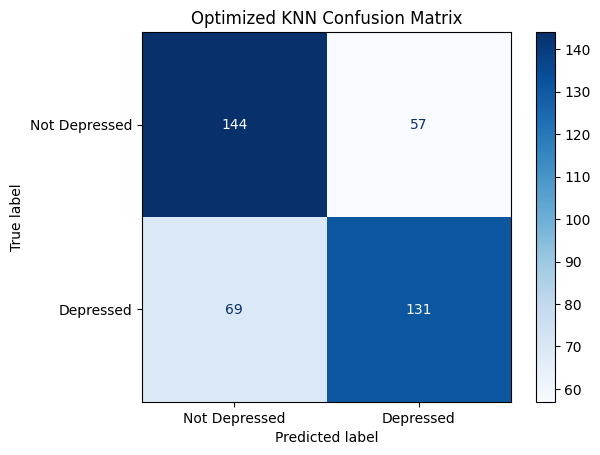

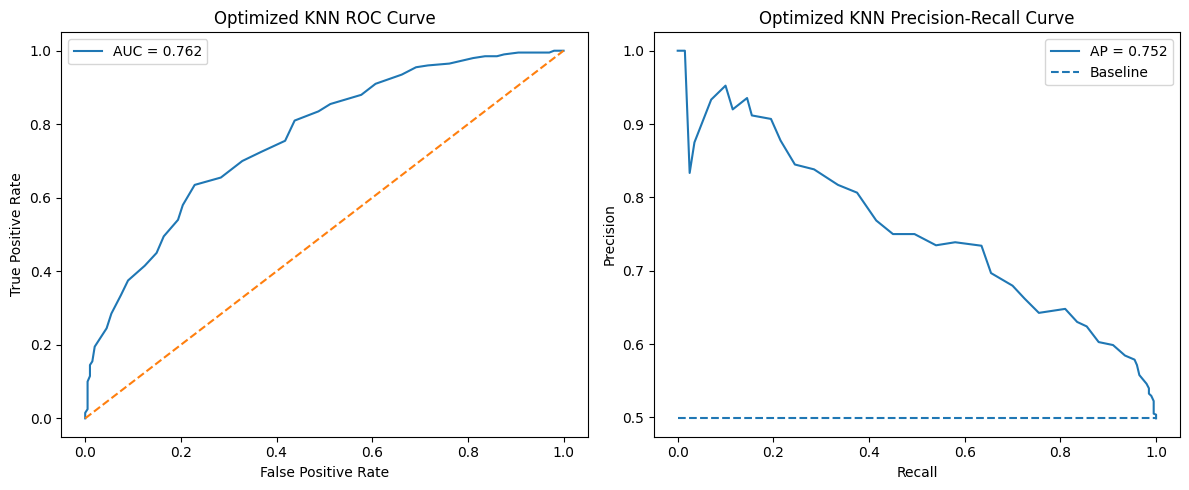

Misclassification Error Rate: 0.3142


In [ ]:
# Evaluate the model
knn_metrics = evaluate_model(
    model=best_knn, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Optimized KNN", 
    show_plots=True
)
print(f"Misclassification Error Rate: {1 - knn_metrics["Accuracy"]:.4f}")

### Feature Importance for KNN

In [ ]:
"""
In order to determine which features the KNN model relied the most on we can use a model-agnostic technique called Permutation Importance.
Essentially it works by randomly shuffling the values of the features until they become total garbage, and seeing how much the model's AUC drops. If the AUC model drops massively, that feature was highly important.
"""
from sklearn.inspection import permutation_importance
import pandas as pd

print("Calculating KNN Permutation Importance...")

# Calculate permutation importance using our best metric (AUC)
perm_results = permutation_importance(
    estimator=best_knn, 
    X=X_test_processed, 
    y=y_test, 
    scoring='roc_auc', 
    n_repeats=5,
    random_state=config.SEED, 
    n_jobs=-1
)

# Create a clean dataframe to view the results
knn_importances = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance_Drop": perm_results.importances_mean
})
knn_importances = knn_importances.sort_values(by="Importance_Drop", ascending=False)

print("\n--- Top 10 Features Driving KNN Predictions ---")
print(knn_importances.head(10).to_string(index=False))

Calculating KNN Permutation Importance...

--- Top 10 Features Driving KNN Predictions ---
        Feature  Importance_Drop
num__AdjDE_diff         0.037353
num__AdjOE_diff         0.022746
  num__WAB_diff         0.010955
  num__TOR_diff         0.004769
 num__EFG%_diff        -0.000430
num__EFGD%_diff        -0.001017
num__ADJ T_diff        -0.003425
  num__DRB_diff        -0.004647
  num__ORB_diff        -0.006604
 num__TORD_diff        -0.012378


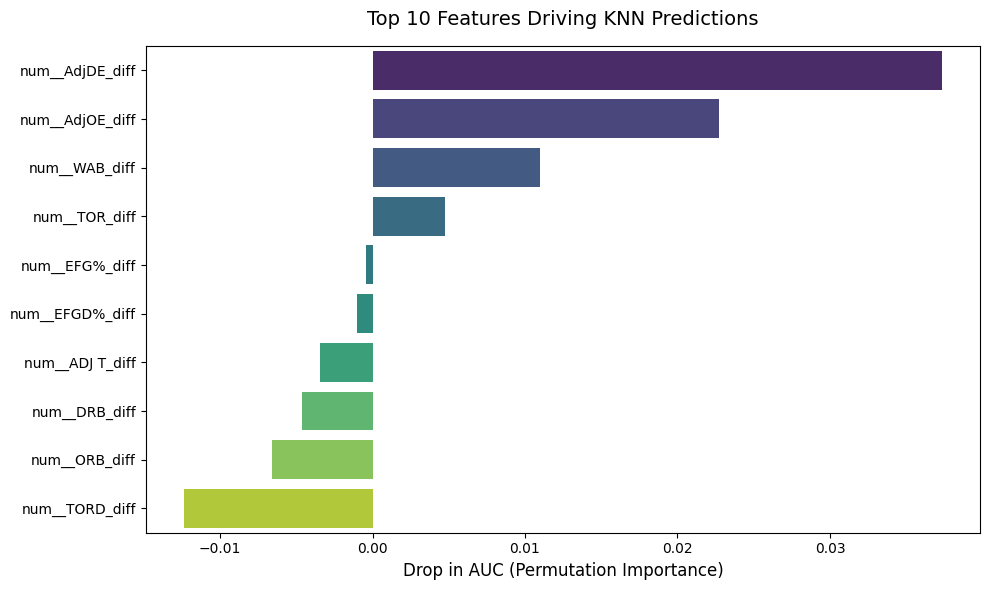

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the 'knn_importances' dataframe we created earlier
plt.figure(figsize=(10, 6))
# Plot only the top 10 to keep the slide clean
sns.barplot(
    x="Importance_Drop", 
    y="Feature", 
    data=knn_importances.head(10), 
    palette="viridis",
    hue='Feature'
)

plt.title("Top 10 Features Driving KNN Predictions", fontsize=14, pad=15)
plt.xlabel("Drop in AUC (Permutation Importance)", fontsize=12)
plt.ylabel("") # Hide the 'Feature' label since it's obvious
plt.tight_layout()
plt.show()

### PCA Decision Boundary Graph

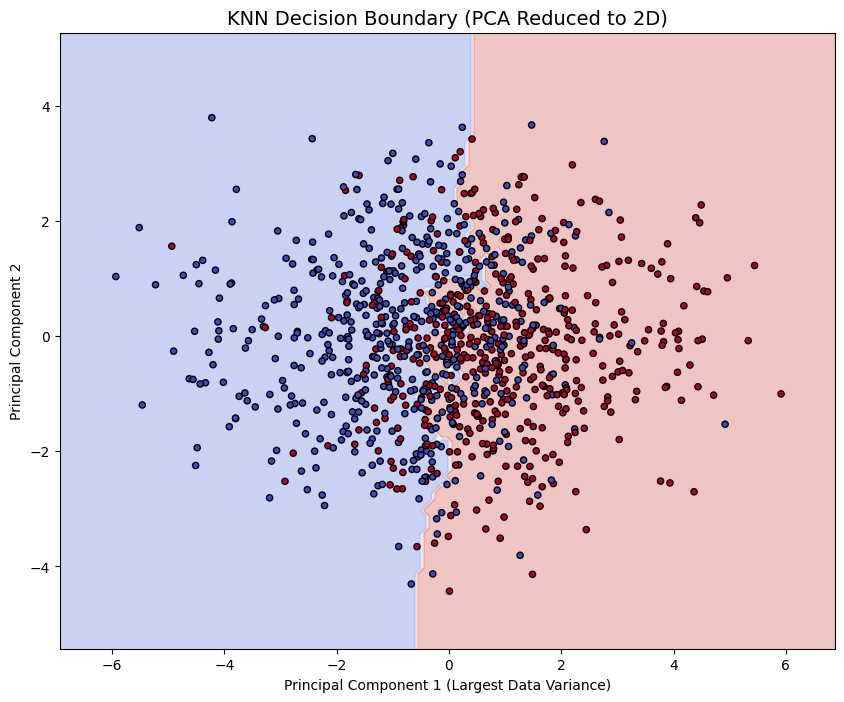

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 1. Squash the 46D data down to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

best_knn_params = grid_search_knn.best_params_
# 2. Train a quick KNN specifically on this 2D data using the best parameters
knn_2d = KNeighborsClassifier(
    n_neighbors=best_knn_params["n_neighbors"], 
    weights=best_knn_params["weights"], 
    metric=best_knn_params["metric"]
)
knn_2d.fit(X_train_pca, y_train)

# 3. Create a mesh grid to draw the background colors
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the class for every point on that grid
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot it
plt.figure(figsize=(10, 8))

# Draw the boundary regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Plot a sample
if config.PCA_SAMPLE:
    sample_idx = np.random.choice(X_train_pca.shape[0], config.PCA_SAMPLE, replace=False)
    pca_data_x = X_train_pca[sample_idx, 0]
    pca_data_y = X_train_pca[sample_idx, 1],
    pca_c = y_train.iloc[sample_idx]
else:
    pca_data_x = X_train_pca[:, 0]
    pca_data_y = X_train_pca[:, 1]
    pca_c = list(y_train.iloc)

plt.scatter(
    pca_data_x,
    pca_data_y, 
    c=pca_c, 
    cmap="coolwarm", 
    edgecolor='k', 
    s=20
)

plt.title("KNN Decision Boundary (PCA Reduced to 2D)", fontsize=14)
plt.xlabel("Principal Component 1 (Largest Data Variance)")
plt.ylabel("Principal Component 2")
plt.show()

# Tree-Based Methods

## Single Decision Tree

Single Decision tree

--- Decision Tree (Depth 4) Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       201
           1       0.74      0.62      0.68       200

    accuracy                           0.70       401
   macro avg       0.71      0.70      0.70       401
weighted avg       0.71      0.70      0.70       401

ROC-AUC: 0.7790
Brier Score: 0.1943
MCC: 0.4112


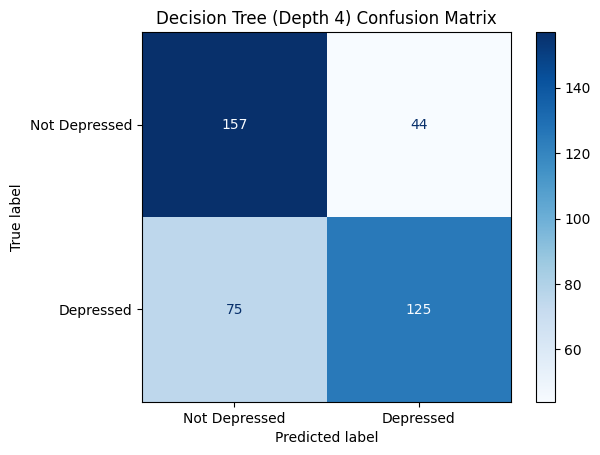

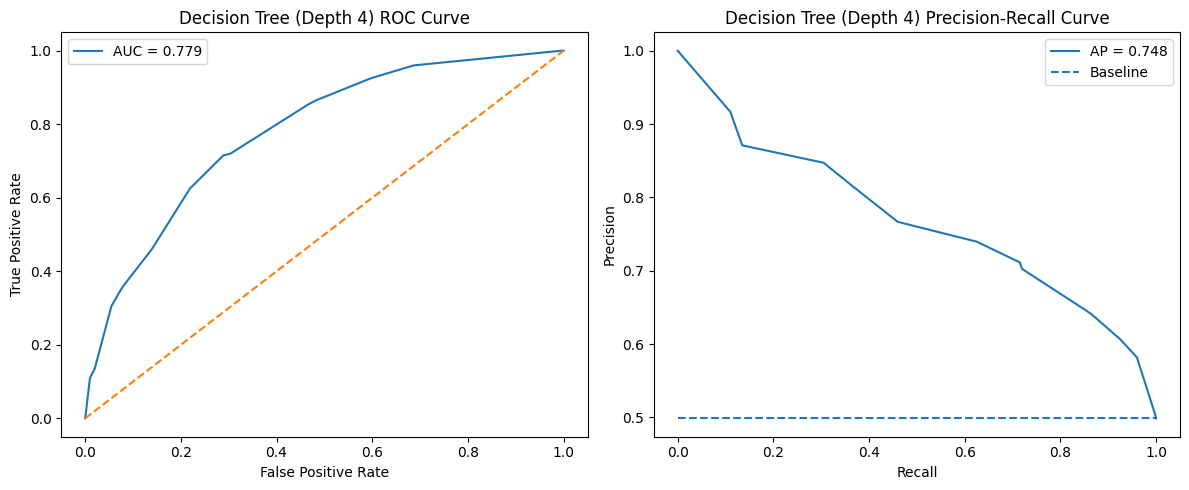

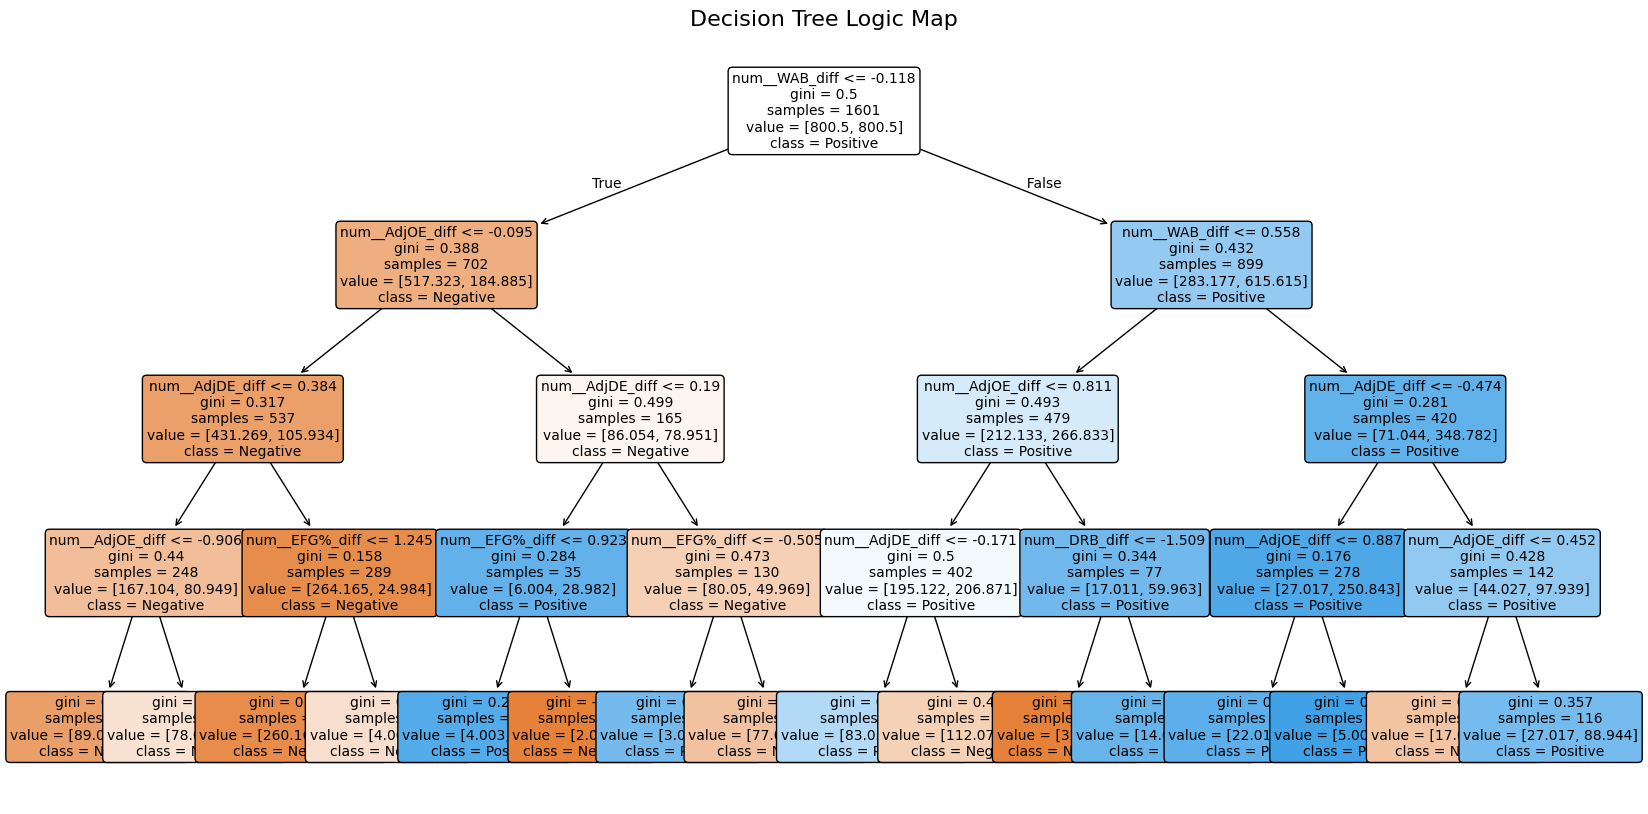

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("="*50)
print("Single Decision tree")
print("="*50)

# We limit max_depth to 4 so it doesn't overfit and we can actually visualize it
dt_model = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=config.SEED)
dt_model.fit(X_train_processed, y_train)
single_tree_metrics = evaluate_model(dt_model, X_test_processed, y_test, name="Decision Tree (Depth 4)")

# Draw the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    feature_names=preprocessor.get_feature_names_out(), 
    class_names=["Negative", "Positive"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Logic Map", fontsize=16)
plt.show()

## Random Forest (Bagging)


Random Forest

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       201
           1       0.72      0.68      0.70       200

    accuracy                           0.71       401
   macro avg       0.71      0.71      0.71       401
weighted avg       0.71      0.71      0.71       401

ROC-AUC: 0.7633
Brier Score: 0.2000
MCC: 0.4121


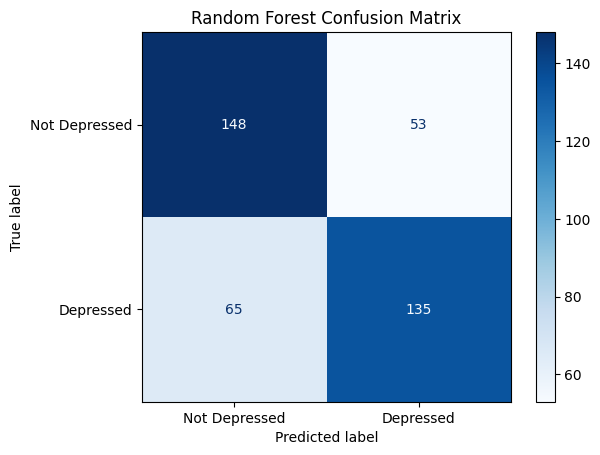

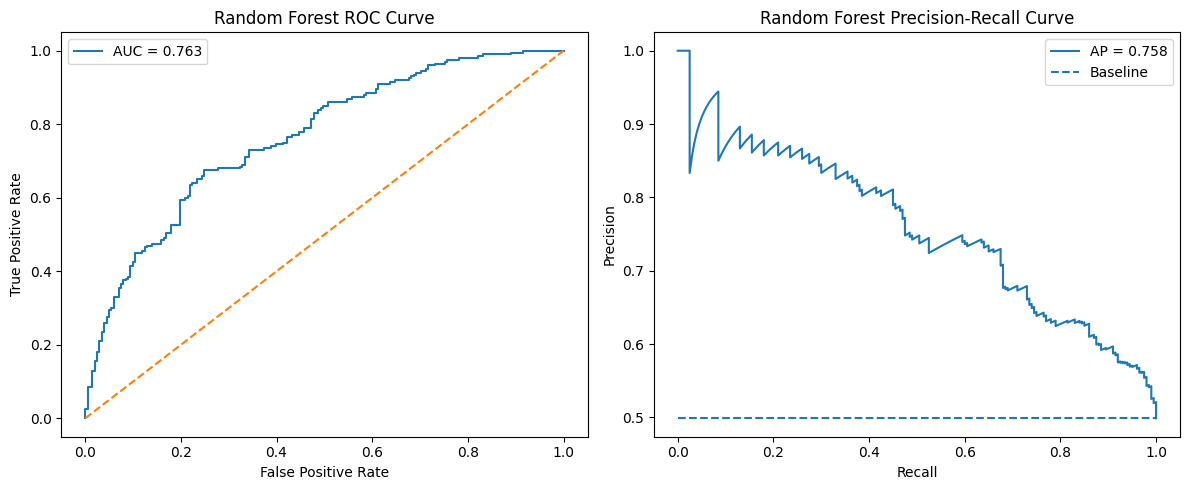

In [ ]:
print("\n" + "="*50)
print("Random Forest")
print("="*50)
# Bagging builds hundreds of independent trees on random subsets of data and averages their votes
rf_model = RandomForestClassifier(
    n_estimators=150,      # Build 150 different trees
    max_depth=12,          # Let them grow fairly deep
    class_weight="balanced", 
    n_jobs=-1,             # Use all CPU cores
    random_state=config.SEED
)
rf_model.fit(X_train_processed, y_train)

random_forest_metrics = evaluate_model(rf_model, X_test_processed, y_test, name="Random Forest")

## Gradient Boosting


Gradient Boosting

--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.70      0.67       201
           1       0.67      0.63      0.65       200

    accuracy                           0.66       401
   macro avg       0.66      0.66      0.66       401
weighted avg       0.66      0.66      0.66       401

ROC-AUC: 0.7468
Brier Score: 0.2250
MCC: 0.3273


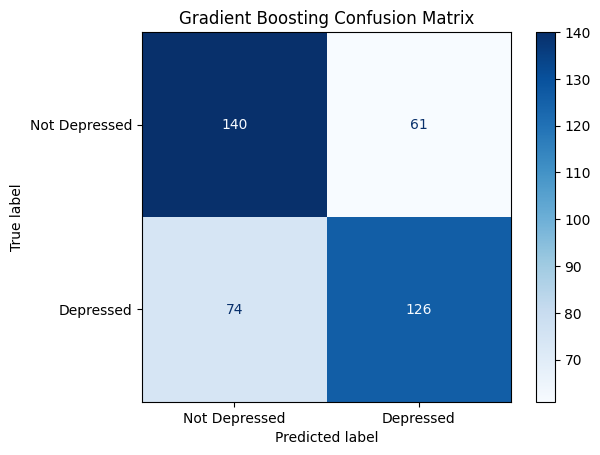

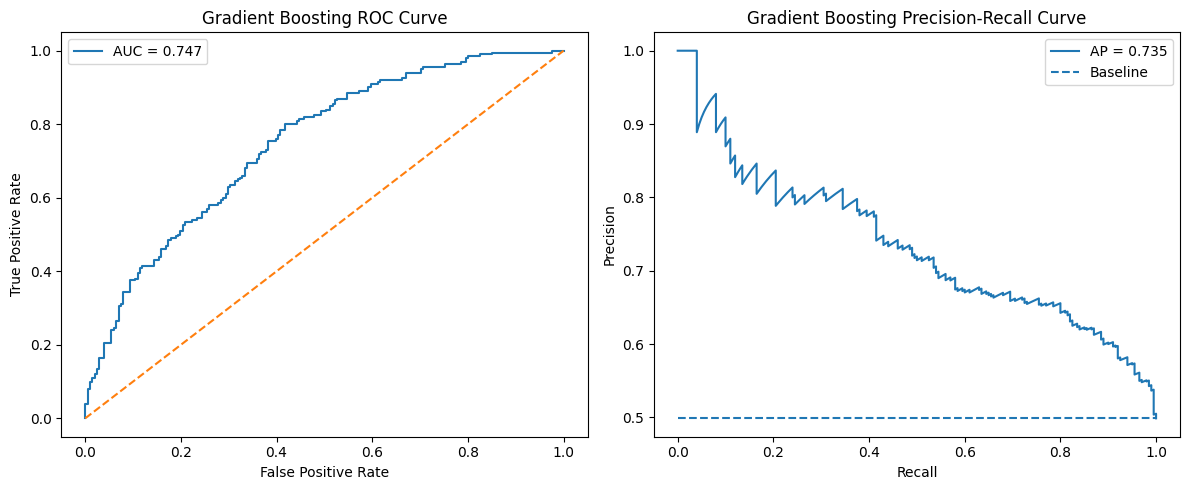


Feature Importances
Top 10 Most Important Features (Gradient Boosting):
        Feature Importance
num__AdjOE_diff     26.77%
num__AdjDE_diff     19.89%
  num__WAB_diff     17.91%
  num__DRB_diff      5.98%
 num__TORD_diff      5.89%
num__ADJ T_diff       5.7%
  num__TOR_diff      5.31%
 num__EFG%_diff      4.77%
num__EFGD%_diff      4.04%
  num__ORB_diff      3.75%


In [ ]:
print("\n" + "="*50)
print("Gradient Boosting")
print("="*50)
# Boosting builds trees sequentially. Each new tree specifically tries to fix the errors of the previous tree.
gb_model = GradientBoostingClassifier(
    n_estimators=150, 
    learning_rate=0.1,     # How much each tree contributes
    max_depth=5,           # Boosted trees should be shallow (weak learners)
    random_state=config.SEED
)
gb_model.fit(X_train_processed, y_train)
gradient_boosting_metrics = evaluate_model(gb_model, X_test_processed, y_test, name="Gradient Boosting")

print("\n" + "="*50)
print("Feature Importances")
print("="*50)

# Extracting feature importances from the top performing Gradient Boosting model
tree_importances = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

tree_importances["Importance"] = (tree_importances["Importance"] * 100).round(2).astype(str) + "%"
print("Top 10 Most Important Features (Gradient Boosting):")
print(tree_importances.head(10).to_string(index=False))

# Discriminant Analysis

In [ ]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

## Linear Discriminant Analysis (LDA)


LDA assumes that features are normally distributed and that all classes share the exact same covariance matrix. Instead of merely looking at accuracy, we want to know *which* features LDA is actually utilizing to discriminate between a depressed and non-depressed student.

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_processed, y_train)

# Predictions and Accuracy
lda_pred = lda.predict(X_test_processed)
print(f"LDA Base Accuracy: {accuracy_score(y_test, lda_pred):.4f}")

LDA Base Accuracy: 0.7257


### Feature Importance via LDA Coefficients

Because LDA creates a linear decision boundary, the coefficients of its discriminant directly correspond to feature importance (similar to Logistic Regression or Lasso). Let's plot the top determining factors.

      Feature  Coefficient
0  AdjOE_diff     1.564346
1  AdjDE_diff    -1.354933
2   EFG%_diff    -0.100871
3  EFGD%_diff     0.136290
4    TOR_diff     0.036131
5   TORD_diff    -0.069951
6    ORB_diff    -0.037812
7    DRB_diff     0.309490
8  ADJ T_diff    -0.113168
9    WAB_diff    -0.631926


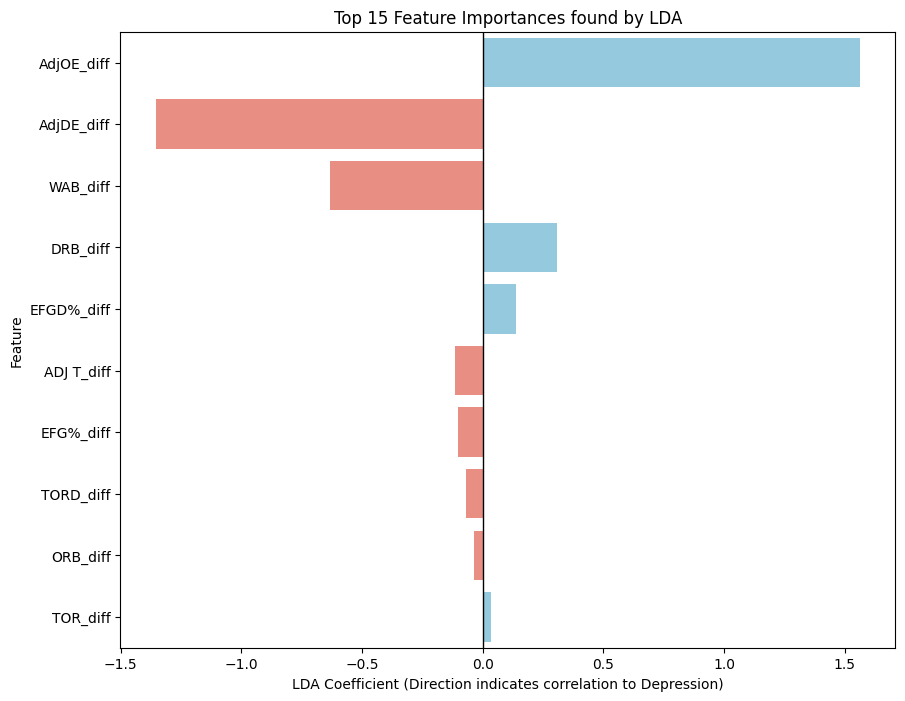

In [ ]:
# Extract weights of the first (and only) linear discriminant for binary classification
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in preprocessor.get_feature_names_out()
]
lda_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lda.coef_[0]
})
print(lda_coefs)

# Calculate absolute importance for sorting
lda_coefs['Absolute_Importance'] = lda_coefs['Coefficient'].abs()
lda_coefs = lda_coefs.sort_values(by='Absolute_Importance', ascending=False)

# Safely build the color palette as a Python list
colors = ['salmon' if x < 0 else 'skyblue' for x in lda_coefs['Coefficient'].head(15)]

# Plot Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=lda_coefs.head(15), 
    hue='Feature',
    palette=colors,
    legend=False
)
plt.title("Top 15 Feature Importances found by LDA")
plt.xlabel("LDA Coefficient (Direction indicates correlation to Depression)")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.show()

### Dimensionality Reduction and Visualizing the Decision Space

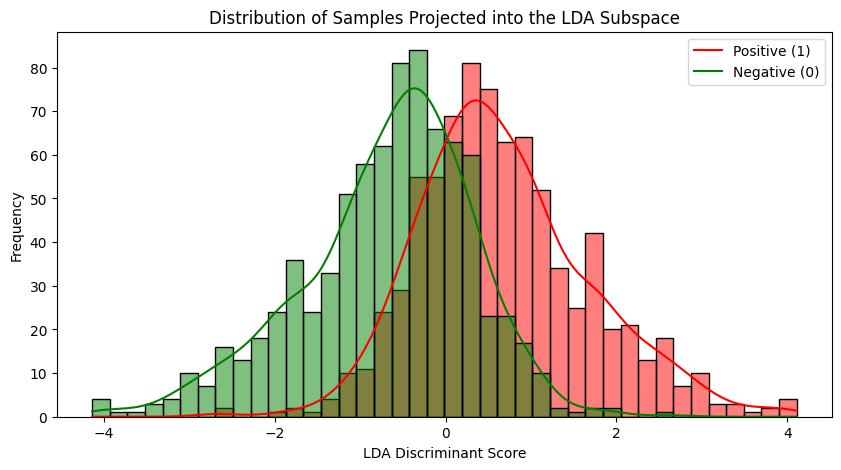

In [ ]:
# Transform data into the 1D LDA space
X_train_lda = lda.transform(X_train_processed).flatten()

# Create a DataFrame for easiest plotting
lda_proj_df = pd.DataFrame({
    'LDA_Score': X_train_lda,
    'Actual_Depression': y_train
})

plt.figure(figsize=(10, 5))
sns.histplot(data=lda_proj_df, x='LDA_Score', hue='Actual_Depression', kde=True, bins=40, palette=['green', 'red'], alpha=0.5)
plt.title("Distribution of Samples Projected into the LDA Subspace")
plt.xlabel("LDA Discriminant Score")
plt.ylabel("Frequency")
plt.legend(['Positive (1)', 'Negative (0)'])
plt.show()


### Evaluation


--- LDA Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       201
           1       0.74      0.69      0.72       200

    accuracy                           0.73       401
   macro avg       0.73      0.73      0.73       401
weighted avg       0.73      0.73      0.73       401

ROC-AUC: 0.8115
Brier Score: 0.1768
MCC: 0.4521


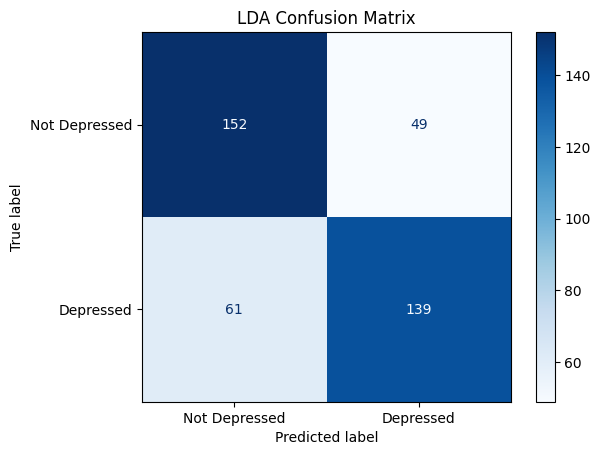

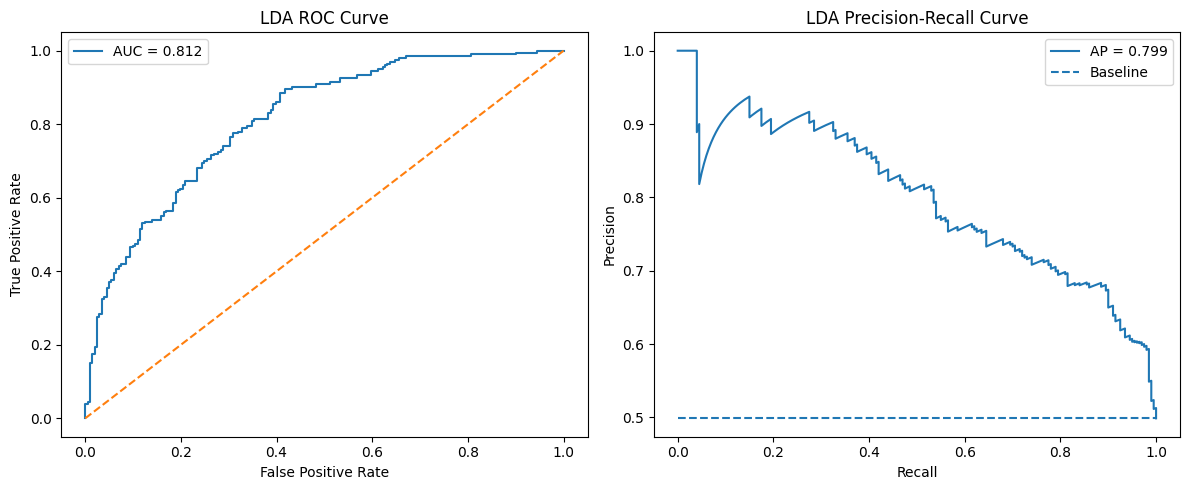

In [ ]:
lda_metrics = evaluate_model(lda, X_test_processed, y_test, "LDA")

## Quadratic Discriminant Analysis (QDA)

QDA relaxes the LDA constraint, allowing each class to have its own unique covariance matrix. This means it can capture complex feature interactions.

However, estimating multiple covariance matrices is highly susceptible to collinearity—especially when using sparse dummy variables. We will perform Grid Search to find the optimal `reg_param` (shrinkage) mathematically, preventing matrix singularity while tuning the model.

In [ ]:
# 5-Fold Cross Validation tuning
qda_grid = GridSearchCV(
    QuadraticDiscriminantAnalysis(),
    {"reg_param": [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 0.8]},
    cv=5, scoring="accuracy",
)
qda_grid.fit(X_train_processed, y_train)

best_qda = qda_grid.best_estimator_

print(f"Optimal QDA reg_param: {qda_grid.best_params_['reg_param']}")

# Final QDA Evaluation
qda_pred = best_qda.predict(X_test_processed)
print(f"Regularized QDA Accuracy: {accuracy_score(y_test, qda_pred):.4f}")


Optimal QDA reg_param: 0.8
Regularized QDA Accuracy: 0.7032


### Evaluation


--- QDA Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       201
           1       0.71      0.68      0.69       200

    accuracy                           0.70       401
   macro avg       0.70      0.70      0.70       401
weighted avg       0.70      0.70      0.70       401

ROC-AUC: 0.7826
Brier Score: 0.1967
MCC: 0.4070


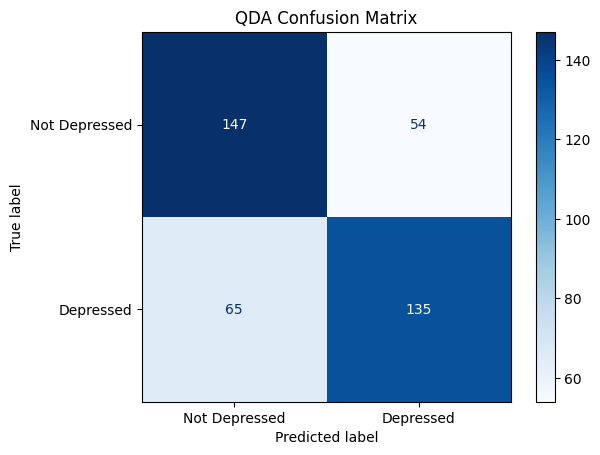

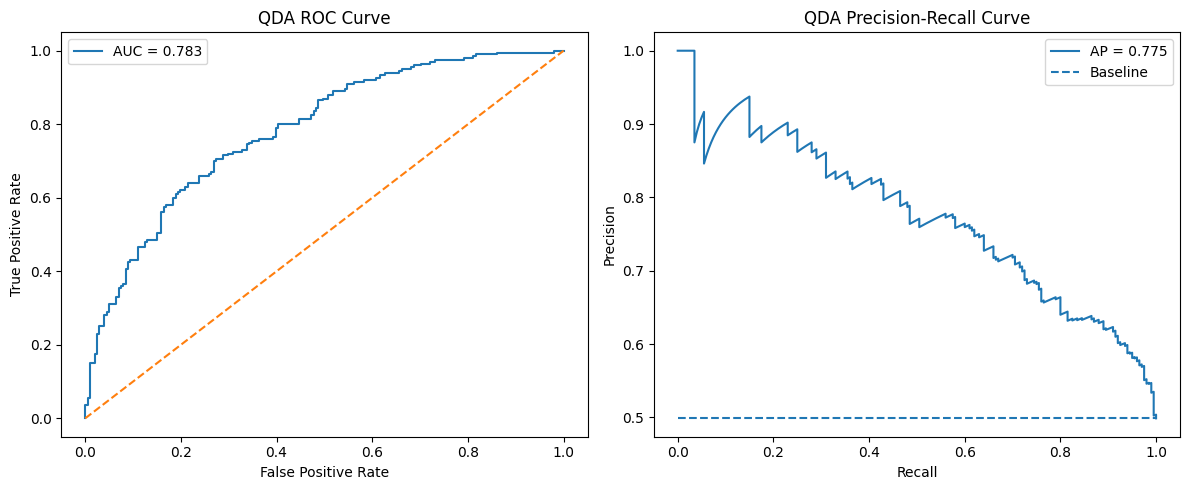

In [ ]:
qda_metrics = evaluate_model(best_qda, X_test_processed, y_test, "QDA")

# Generalized Additive Model (GAM)

In [ ]:
from pygam import LogisticGAM, s, l

# GAMs cannot work with sparse data, so collapse to an array
X_train_gam = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_gam  = X_test_processed.toarray()  if hasattr(X_test_processed,  "toarray") else X_test_processed
y_train_gam = y_train.values
y_test_gam = y_test.values

print(f"GAM training shape: {X_train_gam.shape}")

GAM training shape: (1601, 10)


In [ ]:
# Build term list from GAM_SMOOTH_COUNT
n_features = X_train_gam.shape[1]
smooth_n   = min(config.GAM_SMOOTH_COUNT, n_features)

terms = s(0)
for i in range(1, smooth_n):
    terms += s(i)
for i in range(smooth_n, n_features):
    terms += l(i)

print(f"GAM terms: {smooth_n} smooth (s), {n_features - smooth_n} linear (l), {n_features} total")

GAM terms: 10 smooth (s), 0 linear (l), 10 total


### Parameter Tuning / Training

In [ ]:
gam_model = LogisticGAM(terms).gridsearch(X_train_gam, y_train_gam)
print(f"Final Optimized Lambda: {gam_model.lam}")
print("GAM model training complete.")


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:13 ETA:   0:02:19
 18% (2 of 11) |####                     | Elapsed Time: 0:00:16 ETA:   0:01:14
 27% (3 of 11) |######                   | Elapsed Time: 0:00:18 ETA:   0:00:48
 36% (4 of 11) |#########                | Elapsed Time: 0:00:20 ETA:   0:00:35
 45% (5 of 11) |###########              | Elapsed Time: 0:00:20 ETA:   0:00:25
 54% (6 of 11) |#############            | Elapsed Time: 0:00:21 ETA:   0:00:18
 63% (7 of 11) |###############          | Elapsed Time: 0:00:22 ETA:   0:00:12
 72% (8 of 11) |##################       | Elapsed Time: 0:00:23 ETA:   0:00:08
 81% (9 of 11) |####################     | Elapsed Time: 0:00:23 ETA:   0:00:05
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:23 ETA:   0:00:02
100% (11 of 11) |########################| Elapsed Time: 0:00:24 Time:  0:00:24


Final Optimized Lambda: [[np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)], [np.float64(1000.0)]]
GAM model training complete.


In [ ]:
print(gam_model.summary())

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     15.0721
Link Function:                        LogitLink Log Likelihood:                                  -782.8459
Number of Samples:                         1601 AIC:                                              1595.836
                                                AICc:                                            1596.1825
                                                UBRE:                                               3.0043
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.2946
Feature Function                  Lam

C:\Users\archa\AppData\Local\Temp\ipykernel_19948\1640218013.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_model.summary())


### Results / Evaluation

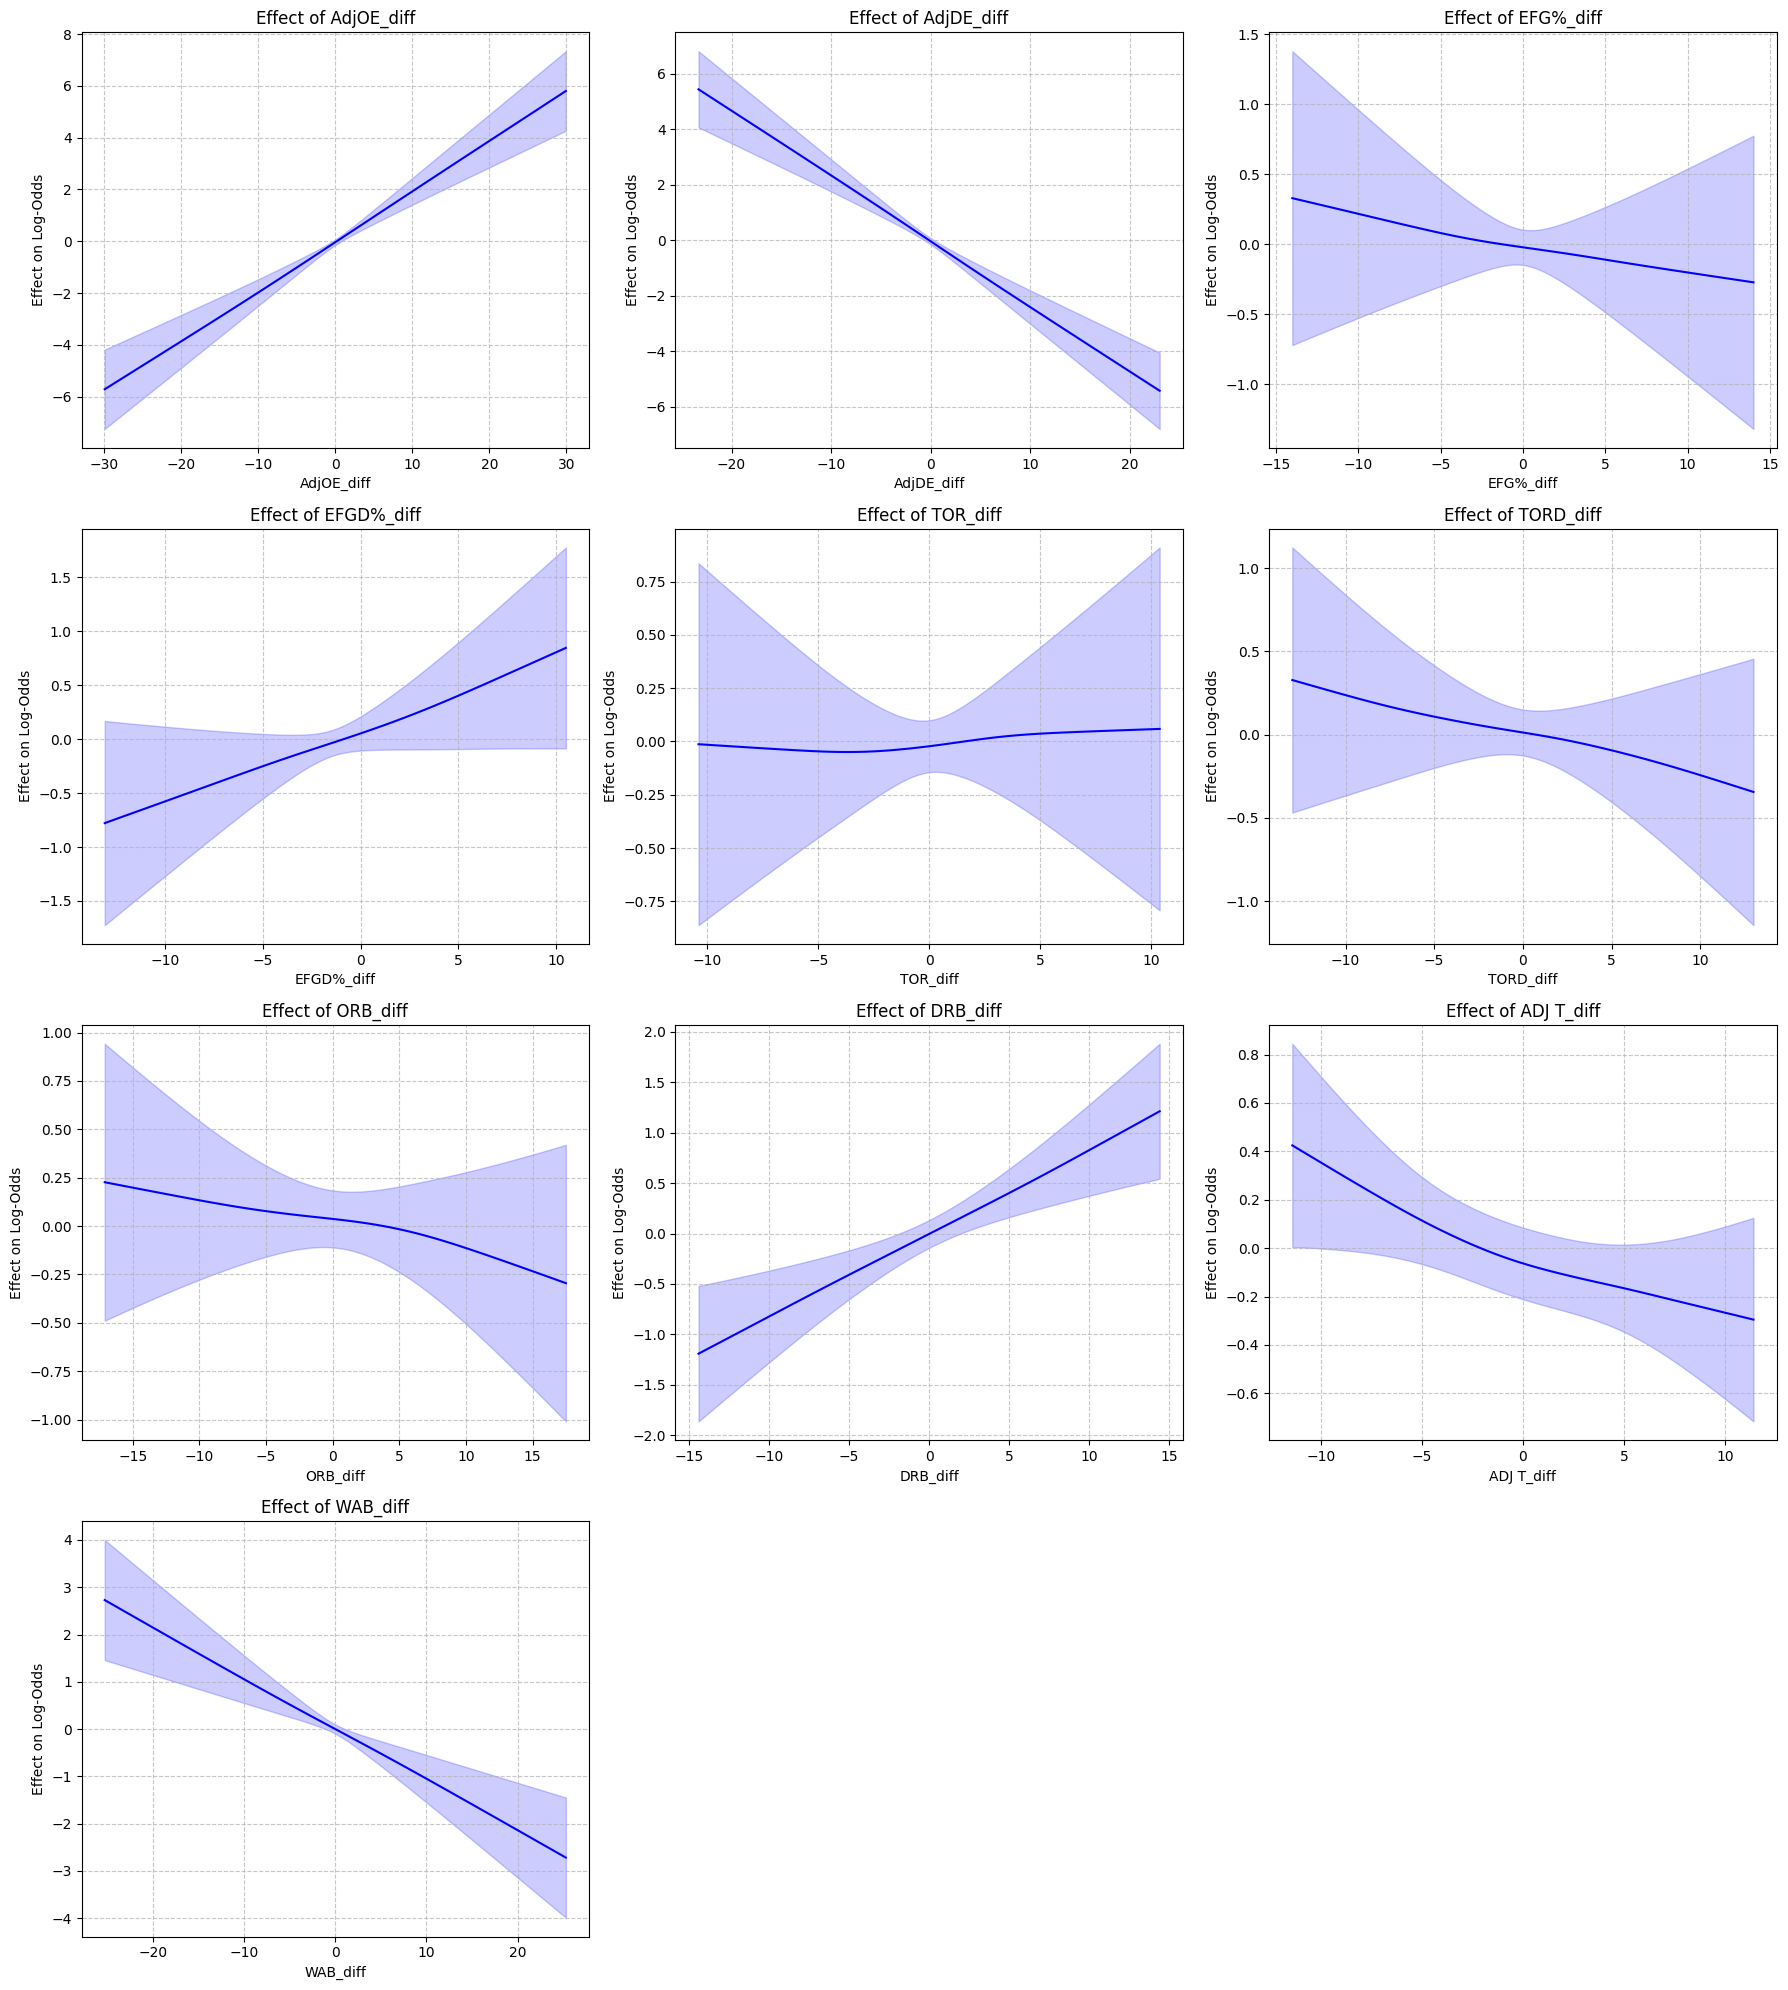

In [ ]:
# Extract the scaler info from the preprocessor
scaler = preprocessor.named_transformers_['num']
means = scaler.mean_
stds = scaler.scale_

# Only plot the base numeric features (not interaction terms)
base_numeric   = [f for f in config.NUMERIC_FEATURES if f in all_numeric]
n_smooth_base  = min(len(base_numeric), smooth_n)
smoothed_idx   = list(range(n_smooth_base))

cols = min(3, n_smooth_base)
rows = (n_smooth_base + cols - 1) // cols

plt.figure(figsize=(6 * cols, 5 * rows))

for plot_i, term_i in enumerate(smoothed_idx):
    plt.subplot(rows, cols, plot_i + 1)
    
    # Generate the grid
    XX = gam_model.generate_X_grid(term=term_i)
    
    # Get partial dependence and confidence intervals
    pdep, confi = gam_model.partial_dependence(term=term_i, width=0.95)
    
    # Convert the x-axis back to original units
    unscaled_x = (XX[:, term_i] * stds[term_i]) + means[term_i]
    
    # Plot using the unscaled values
    plt.plot(unscaled_x, pdep, 'b-', label='Partial Dependence')
    plt.fill_between(unscaled_x, confi[:, 0], confi[:, 1], alpha=0.2, color='blue')
    
    plt.title(f"Effect of {base_numeric[plot_i]}", fontsize=12)
    plt.xlabel(base_numeric[plot_i])
    plt.ylabel('Effect on Log-Odds')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


--- Logistic GAM Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       201
           1       0.73      0.69      0.71       200

    accuracy                           0.72       401
   macro avg       0.72      0.72      0.72       401
weighted avg       0.72      0.72      0.72       401

ROC-AUC: 0.8111
Brier Score: 0.1782
MCC: 0.4368


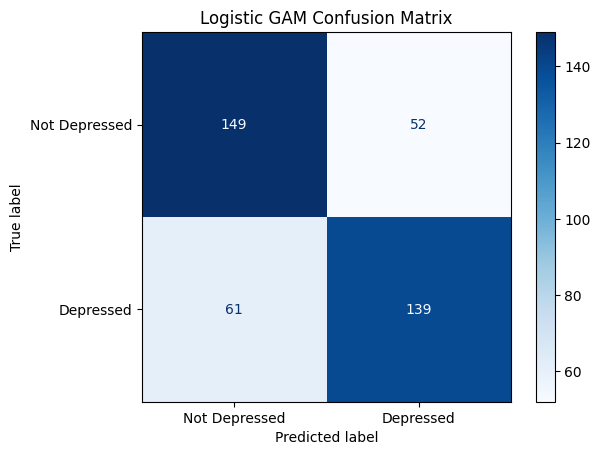

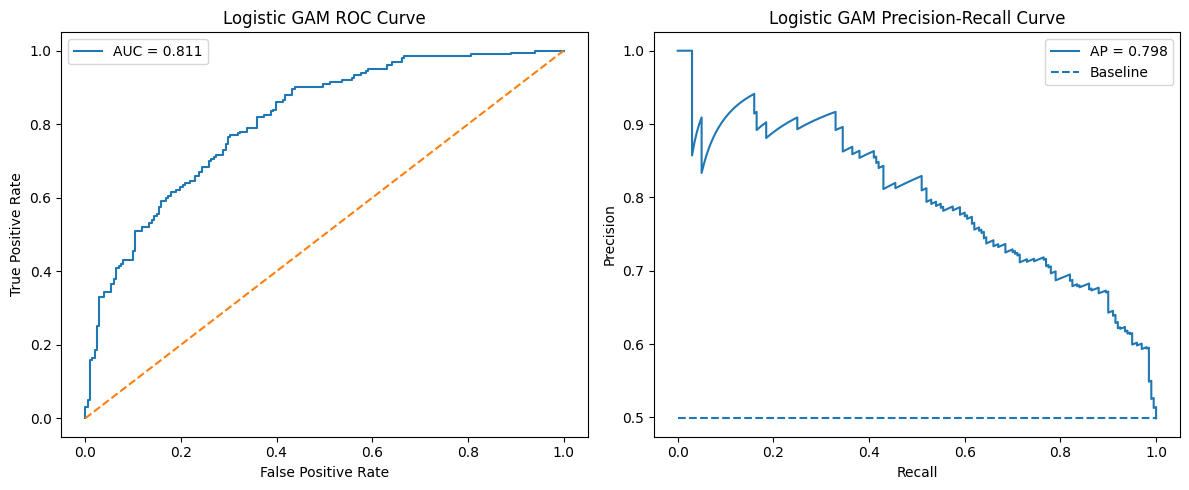

In [ ]:
# Just a wrapper to make the GAM model's proba play nice with the evaluation function
class GamWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = [0, 1]
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        p1 = self.model.predict_proba(X)
        p0 = 1 - p1
        return np.vstack([1-p1, p1]).T

# Wrap your trained model
gam_wrapped = GamWrapper(gam_model)

# Now run your evaluation tool again
gam_metrics = evaluate_model(
    model=gam_wrapped, 
    X_test=X_test_gam, 
    y_test=y_test_gam, 
    name="Logistic GAM"
)

# Support Vector Machines (SVM)

 The main goal of an SVM is to draw the perfect boundary (called a hyperplane) between the two classes: Depressed and Healthy. 

### The Baseline Linear SVM

In [ ]:
from sklearn.svm import SVC
import time

print("Training Baseline Linear SVM: ")
start_time = time.time()
svm_baseline = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=config.SEED)
svm_baseline.fit(X_train_processed, y_train)
print(f"Baseline SVM trained in {time.time() - start_time:.2f} seconds.")

Training Baseline Linear SVM: 
Baseline SVM trained in 0.29 seconds.


### Evaluate


--- Baseline Linear SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       201
           1       0.73      0.69      0.71       200

    accuracy                           0.72       401
   macro avg       0.72      0.72      0.72       401
weighted avg       0.72      0.72      0.72       401

ROC-AUC: 0.8113
Brier Score: 0.1770
MCC: 0.4370


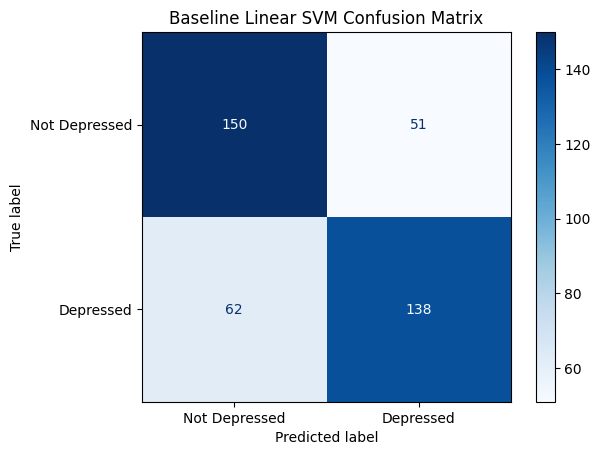

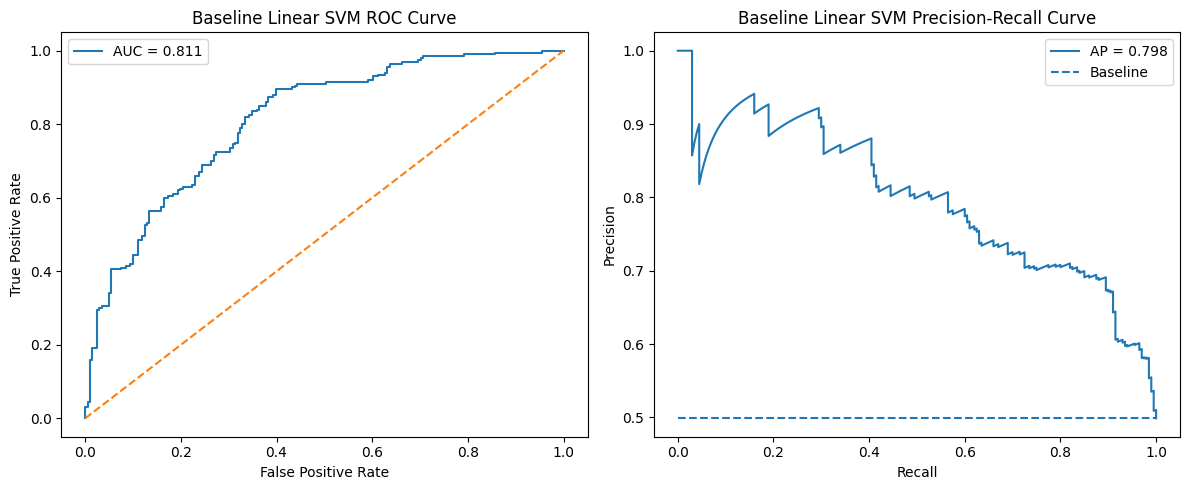

In [ ]:
# Evaluate using evaluate model function
svm_baseline_metrics = evaluate_model(
    model=svm_baseline, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Baseline Linear SVM"
)

### Hyperparameter Tuning (The Kernel Trick)

In [ ]:
# 1. Create a smaller sample so it doesn't take forever to run
if config.SVM_SAMPLE < 1.0:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_processed, y_train, train_size=config.SVM_SAMPLE, random_state=config.SEED, stratify=y_train
    )
else:
    X_tune, y_tune = X_train_processed, y_train

# 2. Define the SVM parameter grid
svm_param_grid = {
    'C': [0.1, 1, 10],                   # Regularization (Low C = more errors allowed)
    'kernel': ['linear', 'rbf']          # 'rbf' is the kernel for non-linear boundaries
}

print("Starting Grid Search for SVM")
svm_grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, random_state=config.SEED),
    param_grid=svm_param_grid,
    cv=3,                # Only 3 folds to save time
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=2            # Verbose=2 gives you live updates
)

svm_grid_search.fit(X_tune, y_tune)

print("\n--- SVM Grid Search Results ---")
print(f"Best Parameters: {svm_grid_search.best_params_}")
print(f"Best Tuning AUC: {svm_grid_search.best_score_:.4f}")

Starting Grid Search for SVM
Fitting 3 folds for each of 6 candidates, totalling 18 fits

--- SVM Grid Search Results ---
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best Tuning AUC: 0.8225


### Training and Evaluating the Final SVM

Training Optimized SVM with linear kernel
Optimized SVM trained in 0.17 seconds.

--- Optimized SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       201
           1       0.73      0.69      0.71       200

    accuracy                           0.72       401
   macro avg       0.72      0.72      0.72       401
weighted avg       0.72      0.72      0.72       401

ROC-AUC: 0.8081
Brier Score: 0.1778
MCC: 0.4319


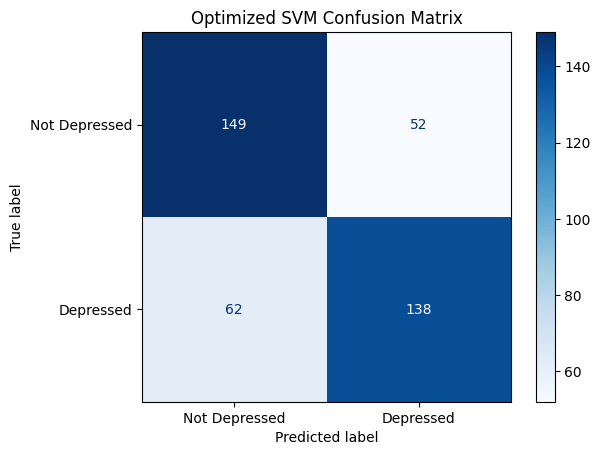

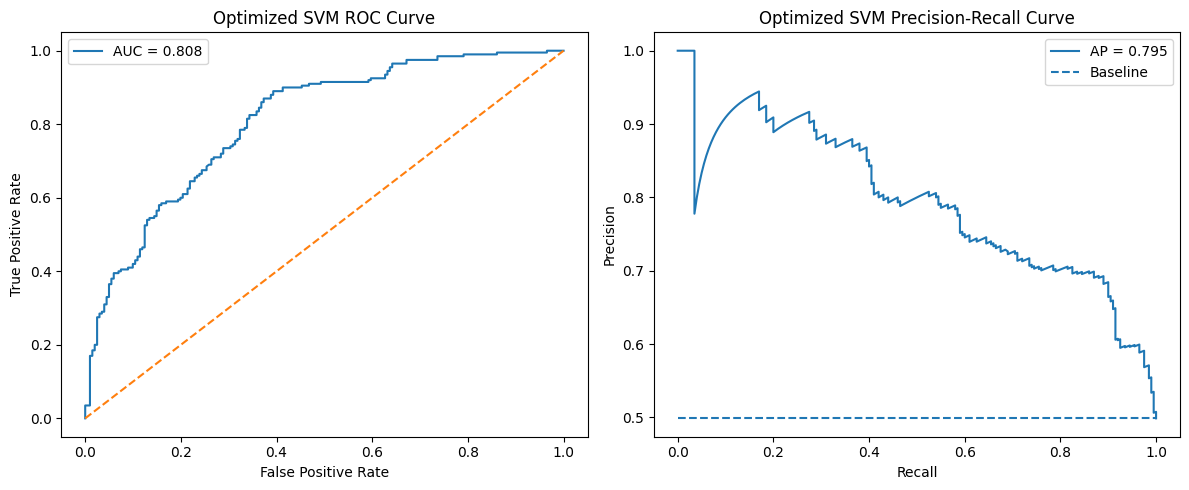

In [ ]:
# Extract the best model configuration from the grid search
best_svm = svm_grid_search.best_estimator_
print(f"Training Optimized SVM with {svm_grid_search.best_params_['kernel']} kernel")

start_time = time.perf_counter()
# Train the winning model on all rows
best_svm.fit(X_train_processed, y_train)

print(f"Optimized SVM trained in {time.perf_counter() - start_time:.2f} seconds.")

# Final Evaluation
svm_optimized_metrics = evaluate_model(
    model=best_svm, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Optimized SVM"
)

### The SVM Feature Weights Bar Chart

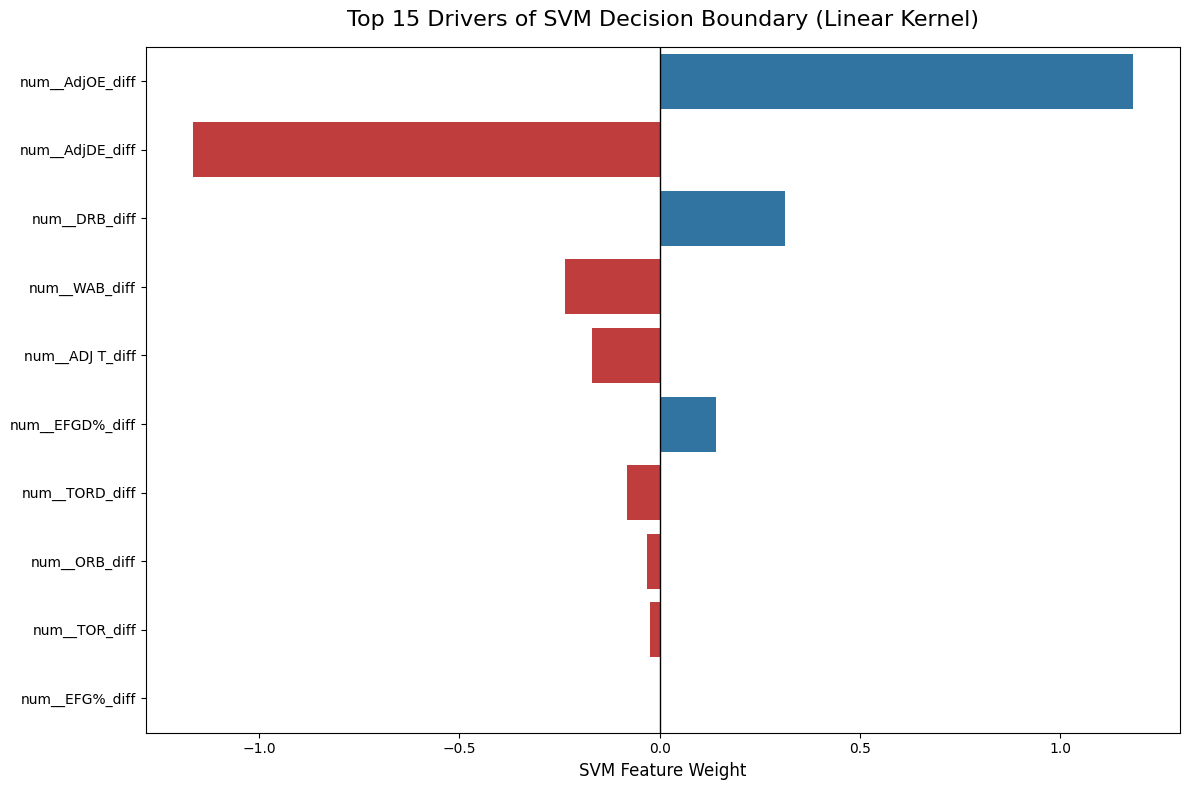

In [ ]:
if svm_grid_search.best_params_["kernel"] == "linear":
    # 1. Extract the coefficients from the optimized linear SVM
    svm_coefs = pd.DataFrame({
        "Feature": preprocessor.get_feature_names_out(),
        "Weight": best_svm.coef_[0]
    })

    # 2. Sort by absolute magnitude to find the strongest drivers (both positive and negative)
    svm_coefs["Abs_Weight"] = svm_coefs["Weight"].abs()
    svm_coefs = svm_coefs.sort_values(by="Abs_Weight", ascending=False).head(15) # Top 15

    # 3. Create a color map: Red for increasing depression risk, Blue for decreasing
    colors = ['#d62728' if w < 0 else '#1f77b4' for w in svm_coefs["Weight"]]

    # 4. Plot the horizontal bar chart
    plt.figure(figsize=(12, 8))
    sns.barplot(x="Weight", y="Feature", data=svm_coefs, palette=colors, hue='Feature')

    plt.title("Top 15 Drivers of SVM Decision Boundary (Linear Kernel)", fontsize=16, pad=15)
    plt.xlabel("SVM Feature Weight", fontsize=12)
    plt.ylabel("")
    plt.axvline(0, color='black', linewidth=1) # Draw the center zero-line
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature weights not available for kernel='{svm_grid_search.best_params_['kernel']}'. "
          f"Use permutation importance instead (see KNN section for example).")

### The PCA Decision Boundary 

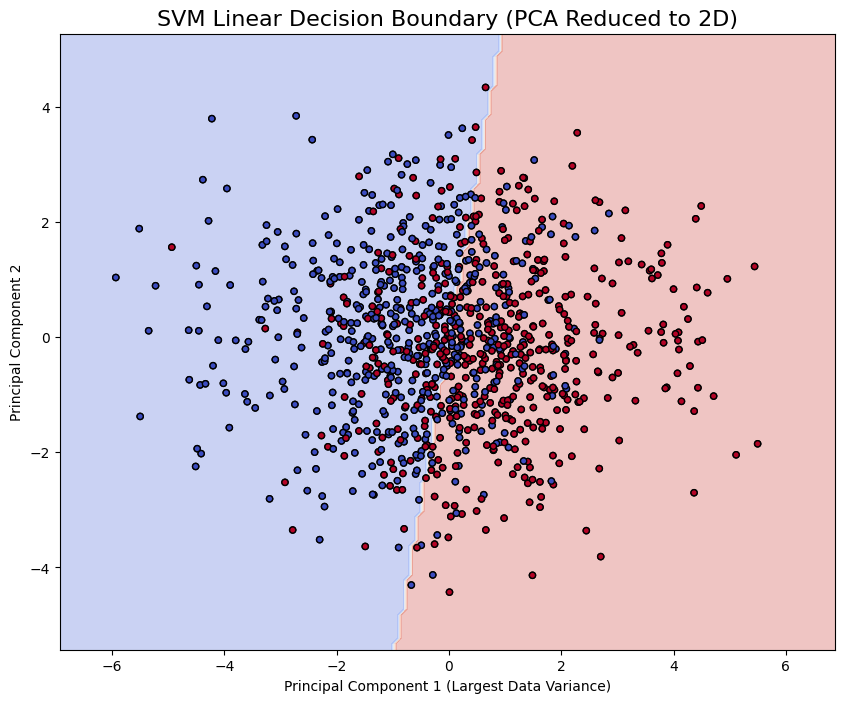

In [ ]:
from sklearn.decomposition import PCA

#Squash the data down to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

# Train a quick Linear SVM specifically on this 2D data
# We use C=0.1 since that was the winning hyperparameter
svm_2d = SVC(kernel='linear', C=0.1, class_weight='balanced', random_state=config.SEED)
svm_2d.fit(X_train_pca, y_train)

# Create the mesh grid background
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the class for every point on that grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the map
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm") # Draws the straight boundary

# Plot a sample
if config.PCA_SAMPLE:
    sample_idx = np.random.choice(X_train_pca.shape[0], config.PCA_SAMPLE, replace=False)
    pca_data_x = X_train_pca[sample_idx, 0]
    pca_data_y = X_train_pca[sample_idx, 1],
    pca_c = y_train.iloc[sample_idx]
else:
    pca_data_x = X_train_pca[:, 0]
    pca_data_y = X_train_pca[:, 1]
    pca_c = list(y_train.iloc)

plt.scatter(
    pca_data_x,
    pca_data_y, 
    c=pca_c, 
    cmap="coolwarm", 
    edgecolor='k', 
    s=20
)

plt.scatter(
    pca_data_x, 
    pca_data_y, 
    c=pca_c, 
    cmap="coolwarm", 
    edgecolor='k', 
    s=20
)

plt.title("SVM Linear Decision Boundary (PCA Reduced to 2D)", fontsize=16)
plt.xlabel("Principal Component 1 (Largest Data Variance)")
plt.ylabel("Principal Component 2")
plt.show()

# Model Evaluation / Comparison

In [ ]:
all_metrics = [
    base_lr_metrics,
    sparse_lr_metrics,
    dl_mlp_metrics,
    knn_metrics,
    single_tree_metrics,
    random_forest_metrics,
    gradient_boosting_metrics,
    lda_metrics,
    qda_metrics,
    gam_metrics,
    svm_baseline_metrics,
    svm_optimized_metrics,
]

comparison_df = pd.DataFrame(all_metrics).set_index("Model")

# Round numerics for readability
comparison_df = comparison_df.round(4)

# Highlight the best value in each column (higher is better except Brier Score)
def highlight_best(s):
    if s.name == "Brier_Score":
        best = s == s.dropna().min()
    else:
        best = s == s.dropna().max()
    return ["background-color: #67c730; font-weight: bold" if v else "" for v in best]

styled = (
    comparison_df
    .style
    .apply(highlight_best)
    .format(na_rep="—", precision=4)
    .set_caption("Model Comparison — Test Set Performance")
)

styled

,ROC-AUC,Brier_Score,Accuracy,Precision,Recall,F1_Score,MCC,AP
Model,,,,,,,,
Full (10 features) Logistic Regression,0.8118,0.1775,0.7257,0.7368,0.7000,0.7179,0.4519,0.7992
Sparse (2 features) Logistic Regression,0.8044,0.1861,0.7107,0.7211,0.6850,0.7026,0.4219,0.7935
Deep Learning MLP,0.7792,0.1937,0.7082,0.7293,0.6600,0.6929,0.4182,0.7656
Optimized KNN,0.7622,0.1976,0.6858,0.6968,0.6550,0.6753,0.3721,0.7516
Decision Tree (Depth 4),0.7790,0.1943,0.7032,0.7396,0.6250,0.6775,0.4112,0.7484
Random Forest,0.7633,0.2000,0.7057,0.7181,0.6750,0.6959,0.4121,0.7577
Gradient Boosting,0.7468,0.2250,0.6633,0.6738,0.6300,0.6512,0.3273,0.7346
LDA,0.8115,0.1768,0.7257,0.7394,0.6950,0.7165,0.4521,0.7994
QDA,0.7826,0.1967,0.7032,0.7143,0.6750,0.6941,0.4070,0.7748
